In [1]:
# # Environment Setup — run this cell first, then restart kernel
# # Tested on Python 3.10 (Anaconda base)
# # ----
# !pip install torch==2.1.0
# !pip install sentence-transformers==2.7.0
# !pip install bertopic==0.15.0
# !pip install umap-learn==0.5.6
# !pip install xgboost==2.0.3
# !pip install shap==0.44.0
# !pip install scikit-learn==1.3.2
# !pip install sympy==1.12
# !pip install pandas numpy scipy matplotlib seaborn altair nbformat

# print("Done. Restart your kernel before running the next cell.")

# Milestone II: YouTube Kids Content - ML Analysis | Spring 2026

## Part 0: Milestone I Summary (Reused Code - EDA & Data Prep)

> **Note on Dataset Changes from Milestone I to Milestone II**
>
> The data cleaning, feature engineering, and EDA code in this section is reused from Milestone I with updates to reflect a revised dataset. No supervised or unsupervised learning code is reused - all ML work begins in Part A below.
>


> **What changed:**
> - **Milestone I** analyzed 5 YouTube kids channels (Cocomelon, ChuChu TV, Vlad & Niki, Kids Diana Show, Masha and the Bear) with 1,825 videos uploaded 2022–2025
> - **Milestone II** focuses exclusively on **Cocomelon** with an expanded dataset of 1,216 videos covering 2015–2026, extracted as of 5/16/2026
> - The new dataset adds a `text` field containing video description text (lyrics or episode narratives), present for ~92% of videos
> - 54 videos with null upload dates were removed, leaving 1,162 videos for analysis
> - The secondary Social Blade dataset (daily channel-level subscriber and view trends) is not included in Milestone II, as the analysis is now single-channel
>
> **What is reused from Milestone I:**
> - Column renaming and data type conversions
> - Duration parsing (string → seconds → minutes)
> - Average daily views metric (`avg_views_per_day = view_count / days_since_upload`)
> - Time-based feature creation (upload day, month, week)
> - EDA visualizations — charts now reflect Cocomelon only rather than 5 channels
>
> **What is new in Milestone II:**
> - Single-channel filter applied at load time (all rows are Cocomelon)
> - Null date handling (`dropna` on `date` before any date-based operations)
> - `text` field preserved for use in Part B description preprocessing pipeline
> - Success threshold (`is_high_performer_tag`) recalculated on the new dataset
> - Multi-channel EDA charts (views by channel, daily views by channel, Social Blade joins) are removed as they are no longer applicable

### Understanding Success Patterns in YouTube Kids Content: Performance Analysis of Top-Performing Channels

In [2]:
import pandas as pd
import numpy as np

from datetime import datetime, timedelta

from scipy import stats
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import altair as alt

# seaborn styles
sns.set_style("darkgrid")
sns.set_palette("viridis")
sns.set_context("paper")

### Part 1: Data Cleaning and Manipulation

### Data Sources

### Part 1: Data Cleaning and Manipulation

The following code is reused from Milestone I with modifications for the updated Cocomelon-only dataset.
Column names, duration parsing, and the average daily views metric are unchanged.
The secondary Social Blade dataset is not used in Milestone II.

**Data Sources**

We obtained our dataset through the Apify platform, which provides structured access to YouTube's Data API v3
(https://developers.google.com/youtube/v3). The dataset contains all Cocomelon videos from channel inception
through 5/16/2026, including both channel-level data (subscriber counts, total views) and video-level metrics
(view counts, upload timestamps, durations, titles, descriptions). This single-channel focus enables deeper
analysis of Cocomelon's content strategy without cross-channel noise.

**Primary Data**

Channel: Cocomelon - Nursery Rhymes (single channel)  
Timeframe: February 2015 – May 2026  
Total videos: 1,216 raw (1,162 after removing 54 null-date records)

### Information on Fields in Primary Dataset

*   `id`: unique ID of the episode
*   `title`: title of episode
*   `url`: URL address for episode
*   `date`: date and time episode was uploaded
*   `duration`: duration of the episode
*   `viewCount`: number of episode views from upload date to 5/16/2026
*   `likes`: number of likes from episode upload date to 5/16/2026
*   `channelName`: name of the YouTube channel
*   `channelId`: unique ID of the Youtube channel
*   `channelUrl`: URL address for the channel
*   `channelJoinedDate`: date channel joined YouTube
*   `numberOfSubscribers`: number of channel subscribers as of 5/16/2026
*   `channelTotalViews`: number of channel views as of 5/16/2026
*   `channelTotalVideos`: number of videos on the channel as of 5/16/2026
*   `text`: video description text (lyrics or episode narrative; present for ~90% of videos)
*   `extractedAt`: date of data extraction

In [3]:
# run the 2 commands below to connect to google drive
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# run commands below to naviagate to current project directory
import os
# change to the project directory
# os.chdir('/content/drive/MyDrive/0_UMich_MADS/Milestone_2/youtube-kids-content-strategy/')  # replace with your exact folder name

In [5]:
video_data = pd.read_csv('data/video_data_v2.csv')

### Sample of Primary Data

In [6]:
video_data.head(2)

,id,title,url,date,duration,viewCount,likes,channelName,channelId,channelUrl,channelJoinedDate,numberOfSubscribers,channelTotalViews,channelTotalVideos,text,extractedAt
0,5Es-WhgMM1o,"Baking Muffins with JJ, Cody, and Nina 🧁 | Sup...",https://www.youtube.com/watch?v=5Es-WhgMM1o,2026-05-16 07:00:04+00:00,00:04:52,184758,441,Cocomelon - Nursery Rhymes,UCbCmjCuTUZos6Inko4u57UQ,https://www.youtube.com/channel/UCbCmjCuTUZos6...,"Sep 1, 2006",201000000,221583842855,1996,Superheroes need healthy snacks to stay strong...,2026-05-16T21:00:00.000Z
1,88kMgs1Cyfw,Celebrate International Women’s Day with CoCom...,https://www.youtube.com/watch?v=88kMgs1Cyfw,2026-03-07 08:00:06+00:00,00:06:16,3116140,2600,Cocomelon - Nursery Rhymes,UCbCmjCuTUZos6Inko4u57UQ,https://www.youtube.com/channel/UCbCmjCuTUZos6...,"Sep 1, 2006",201000000,221583842855,1996,"Happy International Women’s Day! 🌸 Today, we’r...",2026-05-16T21:00:00.000Z


### Unique Channel List - Primary Data

In [7]:
print(video_data['channelName'].unique())

['Cocomelon - Nursery Rhymes']


In [8]:
video_data[['channelName', 'channelUrl','channelId' ]].drop_duplicates()

,channelName,channelUrl,channelId
0,Cocomelon - Nursery Rhymes,https://www.youtube.com/channel/UCbCmjCuTUZos6...,UCbCmjCuTUZos6Inko4u57UQ


### Update column name format

In [9]:
# rename columns from camelCase to snake_case for better data analysis readability
column_mapping = {
    'viewCount': 'view_count',
    'channelName': 'channel_name',
    'channelId': 'channel_id',
    'channelUrl': 'channel_url',
    'channelJoinedDate': 'channel_joined_date',
    'numberOfSubscribers': 'number_of_subscribers',
    'channelTotalViews': 'channel_total_views',
    'channelTotalVideos': 'channel_total_videos',
    'extractedAt': 'extracted_at'
}

video_data.rename(columns=column_mapping, inplace=True)

### Update channel name

In [10]:
# create shorter channel name for better readability on charts and figures

video_data['channel_name_short'] = 'Cocomelon'


### Clean data

In [11]:
# convert date columns to datetime
video_data['date'] = pd.to_datetime(video_data['date'])
video_data['extracted_at'] = pd.to_datetime(video_data['extracted_at'])

# convert duration from HH:MM:SS format to total seconds
video_data['duration_seconds'] = pd.to_timedelta(video_data['duration']).dt.total_seconds().astype(int)

# duration minutes
video_data['duration_minutes'] = video_data['duration_seconds']/60

### Confirm Videos Upload Date Range

In [12]:
earliest_upload = video_data['date'].min()
latest_upload = video_data['date'].max()

print(f"Earliest upload: {earliest_upload.date()} ")
print(f"Latest upload: {latest_upload.date()} ")

Earliest upload: 2015-02-14 
Latest upload: 2026-05-16 


### Check for missing data (NULL values)

<Axes: >

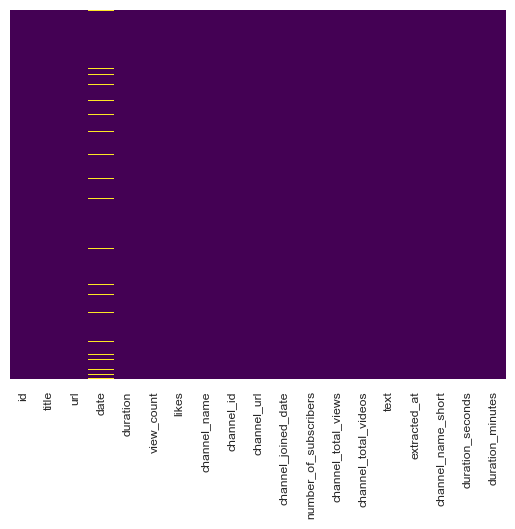

In [13]:
# no yellow tick marks means no missing data
sns.heatmap(video_data.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [14]:
# Remove 54 rows with null dates before date-based feature engineering
video_data = video_data.dropna(subset=['date']).copy()
print(f"Rows after dropping null dates: {len(video_data)}")
# expect: 1162

Rows after dropping null dates: 1162


### Confirm all videos have views

In [15]:
# confirm all videos have view counts
videos_with_views = video_data['view_count'][video_data['view_count'] > 0].count()
videos_no_views = video_data[video_data['view_count'] == 0].count()

print(f"Videos with views: {videos_with_views}")
print(f"Videos with 0 views: {len(video_data[video_data['view_count'] == 0])}")
print(f"Total videos: {len(video_data)}")

Videos with views: 1162
Videos with 0 views: 0
Total videos: 1162


### Create Custom Metric: Average Daily Views

**Average Daily Views** (**Total Views ÷ Days Since Upload**) normalizes performance by controlling for video age, enabling comparisons across content uploaded at different times.

Raw view counts are biased toward older videos - a 2022 video with 15M views might appear more successful than a 2024 video with 5M views, but the newer video could actually be performing better on a per-day basis.

In [16]:
# calculate days since upload
days_since_upload  = (video_data['extracted_at'] - video_data['date']).dt.days   # convert time diff to num days
days_since_upload = days_since_upload.replace(0, 1)  # for same day uploads, replace 0 with 1 so it doesn't cause issues with avg daily views metric

# create column and calcualte avg daily views
video_data['avg_views_per_day'] = video_data['view_count'] / days_since_upload

### Create Time-Based Fields: Upload Day and Month

In [17]:
# upload day of week and upload hour per day
video_data['upload_day_of_week'] = video_data['date'].dt.day_name()
video_data['upload_hour_of_day'] = video_data['date'].dt.hour

# upload month (1-12) and month name (January, February, etc.)
video_data['upload_month'] = video_data['date'].dt.month
video_data['upload_month_name'] = video_data['date'].dt.month_name()

# upload week of year (weeks 1 through 52)
video_data['upload_week'] = video_data['date'].dt.isocalendar().week


In [18]:
video_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1162 entries, 0 to 1215
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id                     1162 non-null   object             
 1   title                  1162 non-null   object             
 2   url                    1162 non-null   object             
 3   date                   1162 non-null   datetime64[ns, UTC]
 4   duration               1162 non-null   object             
 5   view_count             1162 non-null   int64              
 6   likes                  1162 non-null   int64              
 7   channel_name           1162 non-null   object             
 8   channel_id             1162 non-null   object             
 9   channel_url            1162 non-null   object             
 10  channel_joined_date    1162 non-null   object             
 11  number_of_subscribers  1162 non-null   int64              
 1

In [19]:
# Cocomelon average daily views (single channel — summary stat)
print(f"Cocomelon avg daily views per video: {video_data['avg_views_per_day'].mean():,.0f}")

Cocomelon avg daily views per video: 77,304


In [20]:
# Cocomelon Dataset — Preliminary Summary Stats

print("COCOMELON DATASET SUMMARY")
print("-" * 55)
print(f"Total videos:              {len(video_data):,}")
print(f"Date range:                {video_data['date'].min().date()} to {video_data['date'].max().date()}")
print(f"Avg daily views per video: {video_data['avg_views_per_day'].mean():,.0f}")
print(f"Median video duration:     {video_data['duration_minutes'].median():.1f} minutes")
print(f"Videos over 60 minutes:    {(video_data['duration_minutes'] > 60).sum():,}")
print(f"Videos with description (text field):   {(video_data['text'].str.len() > 100).sum():,} ({(video_data['text'].str.len() > 100).mean()*100:.0f}%)")

COCOMELON DATASET SUMMARY
-------------------------------------------------------
Total videos:              1,162
Date range:                2015-02-14 to 2026-05-16
Avg daily views per video: 77,304
Median video duration:     5.6 minutes
Videos over 60 minutes:    91
Videos with description (text field):   1,162 (100%)


---
## Part A: Supervised Learning [NEW]
- Model comparison (Linear Regression, Decision Tree, KNN)
- CV results
- Feature importance
- Failure analysis

### Data Prep

In [21]:
# Copy data for part A - Method 1
cocomelon_df = video_data.copy()
print(f"Total Cocomelon videos: {len(cocomelon_df)}")
print(f"First upload: {cocomelon_df['date'].min()}")
print(f"Last upload:  {cocomelon_df['date'].max()}")

Total Cocomelon videos: 1162
First upload: 2015-02-14 02:03:43+00:00
Last upload:  2026-05-16 07:00:04+00:00


In [22]:
# Exclude Shorts (videos under 60 seconds)
cocomelon_df = cocomelon_df[cocomelon_df['duration_seconds'] > 59].copy()
print(f"After excluding Shorts: {len(cocomelon_df)} videos")


After excluding Shorts: 1158 videos


In [23]:
# Preview table
cocomelon_df.head(2)

,id,title,url,date,duration,view_count,likes,channel_name,channel_id,channel_url,...,extracted_at,channel_name_short,duration_seconds,duration_minutes,avg_views_per_day,upload_day_of_week,upload_hour_of_day,upload_month,upload_month_name,upload_week
0,5Es-WhgMM1o,"Baking Muffins with JJ, Cody, and Nina 🧁 | Sup...",https://www.youtube.com/watch?v=5Es-WhgMM1o,2026-05-16 07:00:04+00:00,00:04:52,184758,441,Cocomelon - Nursery Rhymes,UCbCmjCuTUZos6Inko4u57UQ,https://www.youtube.com/channel/UCbCmjCuTUZos6...,...,2026-05-16 21:00:00+00:00,Cocomelon,292,4.866667,184758.000000,Saturday,7,5,May,20
1,88kMgs1Cyfw,Celebrate International Women’s Day with CoCom...,https://www.youtube.com/watch?v=88kMgs1Cyfw,2026-03-07 08:00:06+00:00,00:06:16,3116140,2600,Cocomelon - Nursery Rhymes,UCbCmjCuTUZos6Inko4u57UQ,https://www.youtube.com/channel/UCbCmjCuTUZos6...,...,2026-05-16 21:00:00+00:00,Cocomelon,376,6.266667,44516.285714,Saturday,8,3,March,10


In [24]:
# Show table columns
cocomelon_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1158 entries, 0 to 1215
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id                     1158 non-null   object             
 1   title                  1158 non-null   object             
 2   url                    1158 non-null   object             
 3   date                   1158 non-null   datetime64[ns, UTC]
 4   duration               1158 non-null   object             
 5   view_count             1158 non-null   int64              
 6   likes                  1158 non-null   int64              
 7   channel_name           1158 non-null   object             
 8   channel_id             1158 non-null   object             
 9   channel_url            1158 non-null   object             
 10  channel_joined_date    1158 non-null   object             
 11  number_of_subscribers  1158 non-null   int64              
 1

### Success Threshold Justification

We define "success" as a Cocomelon video performing at or above the channel's median average
daily views. This threshold was chosen because:

- **Realistic benchmark**: Targets Cocomelon's own baseline, not an extreme outlier
- **Balanced classes**: The 50th percentile splits the dataset evenly (~50% high, ~50% low),
  giving the model equal learning signal from both classes
- **Actionable goal**: A content programming team can use this to identify which format, timing,
  and topic decisions consistently land above Cocomelon's own baseline
- **Age-normalized**: Using average daily views (rather than raw view count) controls for video
  age, allowing fair comparison across videos uploaded across an 11-year catalog

The goal is not to predict a precise percentile — it is to give a content team a reliable signal
about what separates typical Cocomelon performance from below-average performance. The threshold
is channel-relative rather than an arbitrary absolute number, which makes it meaningful regardless
of how view counts shift over time.

An alternative would be a top-quartile cutoff, which would isolate truly breakout videos rather
than above-average ones. We chose the median because it produces balanced classes and better
reflects the practical question a programming team actually faces: which decisions reliably clear
the bar, not just which decisions occasionally produce a viral hit.

**Expected result:** an even 579/579 split between high and low performers out of 1,158 total
videos (after excluding Shorts) — confirming the median threshold delivers perfectly balanced
classes as intended.

In [25]:
# Binary label using existing avg_views_per_day column
success_threshold = cocomelon_df['avg_views_per_day'].quantile(0.5)
cocomelon_df['is_high_performer_tag'] = (cocomelon_df['avg_views_per_day'] >= success_threshold).astype(int)
print(f"Threshold: {success_threshold:,.0f} avg views/day")
print(f"High performers: {cocomelon_df['is_high_performer_tag'].sum()}")
print(f"Low performers:  {(cocomelon_df['is_high_performer_tag']==0).sum()}")

Threshold: 30,295 avg views/day
High performers: 579
Low performers:  579


### Feature Engineering

In [26]:
# Upload day of week
cocomelon_df['upload_day_of_week'] = cocomelon_df['date'].dt.day_name()

# Upload week + upload count per week
cocomelon_df['upload_week'] = cocomelon_df['date'].dt.isocalendar().week
cocomelon_df['upload_year'] = cocomelon_df['date'].dt.year
cocomelon_df['upload_count_per_week'] = cocomelon_df.groupby(
    ['upload_year', 'upload_week']
)['id'].transform('count')

# Upload season
season_bins   = [0, 13, 26, 39, 52] # convert upload week of year (1-52) into seasons to capture seasonal shifts
season_labels = ['Winter (Jan–Mar)', 'Spring (Apr–Jun)', 'Summer (Jul–Sep)', 'Fall (Oct–Dec)']
cocomelon_df['upload_season'] = pd.cut(cocomelon_df['upload_week'], bins=season_bins, labels=season_labels, right=True)

In [27]:
# Video Duration bucket
dur_bins   = [0, 2, 5, 10, 30, 45, np.inf]
dur_labels = ['0-2min', '2-5min', '5-10min', '10-30min', '30-45min', '45min+']
cocomelon_df['duration_bucket'] = pd.cut(cocomelon_df['duration_minutes'], bins=dur_bins, labels=dur_labels, right=True)

In [28]:
# Topic Assignment
# Keywords and categories below were informed by Part B unsupervised clustering.
# BERTopic (k=10) identified 10 content clusters which we collapsed to 6
# content pillars. See Part B for full cluster analysis and 10→4 mapping table.


def quick_map(title, duration_minutes):
    title_lower = title.lower()

    if any(w in title_lower for w in ['wheel', 'bus', 'truck', 'train',
                                       'car', 'vehicle', 'rocket', 'airplane',
                                       'trike', 'recycling']):
        return 'Vehicles'
    elif any(w in title_lower for w in ['christmas', 'halloween', 'holiday',
                                         'easter', 'valentine', 'jingle',
                                         'deck the halls', 'merry']):
        return 'Special_Events'
    elif any(w in title_lower for w in ['lane', 'netflix', 'full episode', 'season']):
        return 'Character_Stories'
    elif any(w in title_lower for w in ['bath', 'wash', 'bedtime', 'lullaby',
                                         'twinkle', 'sleep', 'brush', 'teeth',
                                         'duck', 'quack', 'baa', 'sheep',
                                         'routine', 'goodnight']):
        return 'Educational_Routines'
    elif any(w in title_lower for w in ['abc', 'learn', 'number', 'color',
                                         'shape', 'farm', 'macdonald',
                                         'vegetable', 'fruit', 'apple',
                                         'banana', 'phonics', 'counting']):
        return 'Educational_Learning'
    # Only call it a Compilation if it's actually long enough to be one
    # Anything under 10 minutes that falls through to Compilations gets reassigned to Educational_Learning as a safer default:
    elif duration_minutes >= 10:
        return 'Compilations'
    else:
        return 'Educational_Learning'

cocomelon_df['topic'] = cocomelon_df.apply(
    lambda row: quick_map(row['title'], row['duration_minutes']), axis=1
)

print("Topic distribution:")
print(cocomelon_df['topic'].value_counts())

Topic distribution:
topic
Educational_Learning    529
Compilations            306
Vehicles                120
Educational_Routines    116
Special_Events           79
Character_Stories         8
Name: count, dtype: int64


### Compilation Validation

To confirm the Compilations category reflects actual long-form content rather than
miscategorized single songs, we applied a duration filter: only videos over 10 minutes
are eligible for the Compilations label. Videos that didn't match any keyword pattern
and were under 10 minutes were reassigned to Educational_Learning as the safer default.

The result is a clean Compilations bucket — 306 videos with a median duration of 37.4
minutes and no videos under 10 minutes. All other topics have medians between 3-7
minutes, consistent with single-song format.

Final topic distribution:
- Educational_Learning: 529 videos (broad single-song educational content)
- Compilations: 306 videos (long-form playlist uploads, 30+ min median)
- Vehicles: 120 videos (Wheels on the Bus and vehicle variations)
- Educational_Routines: 116 videos (bath, bedtime, daily routine support)
- Special_Events: 79 videos (holiday and seasonal content)
- Character_Stories: 8 videos (Netflix/CoComelon Lane episodes)

In [29]:
# Validate Compilations category by checking duration distribution
compilation_videos = cocomelon_df[cocomelon_df['topic'] == 'Compilations']

print(f"Total Compilations: {len(compilation_videos)}")
print(f"\nDuration bucket breakdown:")
print(compilation_videos['duration_bucket'].value_counts().sort_index())
print(f"\nMedian duration: {compilation_videos['duration_minutes'].median():.1f} minutes")
print(f"Videos over 10 min: {(compilation_videos['duration_minutes'] > 10).sum()}")
print(f"Videos over 20 min: {(compilation_videos['duration_minutes'] > 20).sum()}")
print(f"Videos over 30 min: {(compilation_videos['duration_minutes'] > 30).sum()}")
print(f"\nFor comparison - all other topics median duration:")
print(cocomelon_df[cocomelon_df['topic'] != 'Compilations'].groupby('topic')['duration_minutes'].median().round(1))

Total Compilations: 306

Duration bucket breakdown:
duration_bucket
0-2min        0
2-5min        0
5-10min       0
10-30min     12
30-45min    193
45min+      101
Name: count, dtype: int64

Median duration: 37.4 minutes
Videos over 10 min: 306
Videos over 20 min: 302
Videos over 30 min: 294

For comparison - all other topics median duration:
topic
Character_Stories       7.3
Educational_Learning    3.1
Educational_Routines    6.2
Special_Events          4.8
Vehicles                5.8
Name: duration_minutes, dtype: float64


As shown in the quick confirmation metrics below, Entertainment is the largest topic
group at 58%, which makes sense given how much of Cocomelon's catalog is general songs
and play content that doesn't fit a specific educational or character-driven theme.
Educational content comes in second at 26%, followed by Character Stories (10%) and
Special Events (5%). Season distribution is well-balanced across all four quarters,
which is what we want for a stratified split.

In [30]:
# Confirm
print(cocomelon_df[['upload_day_of_week','upload_count_per_week',
                     'upload_season','duration_bucket','topic',
                     'is_high_performer_tag']].head(3))
print(f"\nTopic distribution:\n{cocomelon_df['topic'].value_counts()}")
print(f"\nSeason distribution:\n{cocomelon_df['upload_season'].value_counts()}")

  upload_day_of_week  upload_count_per_week     upload_season duration_bucket  \
0           Saturday                      3  Spring (Apr–Jun)          2-5min   
1           Saturday                      3  Winter (Jan–Mar)         5-10min   
3           Thursday                      3  Spring (Apr–Jun)         5-10min   

                  topic  is_high_performer_tag  
0  Educational_Learning                      1  
1  Educational_Learning                      1  
3  Educational_Learning                      1  

Topic distribution:
topic
Educational_Learning    529
Compilations            306
Vehicles                120
Educational_Routines    116
Special_Events           79
Character_Stories         8
Name: count, dtype: int64

Season distribution:
upload_season
Spring (Apr–Jun)    296
Summer (Jul–Sep)    290
Fall (Oct–Dec)      290
Winter (Jan–Mar)    279
Name: count, dtype: int64


### Data Preprocessing

In [31]:
# Check for null values in cocomelon_df before proceeding
# (catch any missing data issues before they cause problems downstream)
print("Null counts across all columns:")
print(cocomelon_df.isnull().sum())

Null counts across all columns:
id                       0
title                    0
url                      0
date                     0
duration                 0
view_count               0
likes                    0
channel_name             0
channel_id               0
channel_url              0
channel_joined_date      0
number_of_subscribers    0
channel_total_views      0
channel_total_videos     0
text                     0
extracted_at             0
channel_name_short       0
duration_seconds         0
duration_minutes         0
avg_views_per_day        0
upload_day_of_week       0
upload_hour_of_day       0
upload_month             0
upload_month_name        0
upload_week              0
is_high_performer_tag    0
upload_year              0
upload_count_per_week    0
upload_season            3
duration_bucket          0
topic                    0
dtype: int64


In [32]:
# No null values found across any column — data is clean, ready to split

In [33]:
from sklearn.model_selection import train_test_split

# Select features (X) and target (y)
# X = the input variables the model uses to make predictions (what we know about each video)
# y = the answer we're trying to predict (was this video a high performer or not?)
X = cocomelon_df[['upload_day_of_week', 'upload_count_per_week',
                   'upload_season', 'duration_bucket', 'topic']]
y = cocomelon_df['is_high_performer_tag']

# Stratified train/test split
# - Splits data into 70% for training the model and 30% for testing it
# - 'stratify=y' ensures both train and test sets have the same ratio of
#   high/low performers (~50/50), preventing class imbalance in either split
# - random_state=101 locks in the split so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=101
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train label balance:\n{y_train.value_counts()}")
print(f"Test label balance:\n{y_test.value_counts()}")

X_train: (810, 5), X_test: (348, 5)
Train label balance:
is_high_performer_tag
0    405
1    405
Name: count, dtype: int64
Test label balance:
is_high_performer_tag
1    174
0    174
Name: count, dtype: int64


### Transform: One Hot Encoding & Scaling

In [34]:
# Categorical columns - will be one-hot encoded
# (converts text categories like 'Tuesday' or 'Educational' into numeric 0/1 columns model can read)
categorical_columns = ['upload_day_of_week', 'upload_season', 'duration_bucket', 'topic']

# Numeric columns - will be scaled (standardized to same range so no single feature dominates / makes feature coefficients directly comparable for interpretability
numeric_columns = ['upload_count_per_week']

### Supervised Method 1: Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Build column transformer
# - OneHotEncoder: converts categorical text columns into numeric 0/1 columns
# - StandardScaler: standardizes numeric columns to mean=0, std=1
column_transformer = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), categorical_columns),
    (StandardScaler(), numeric_columns)
)

# Assemble pipeline: preprocessing + model in one reusable object
# (ensures the same transformations are applied consistently to train and test data)
lr_pipeline = Pipeline([
    ('pre_process', column_transformer),
    ('model', LogisticRegression(max_iter=1000))
])

# Fit the model on training data
lr_pipeline.fit(X_train, y_train)
print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


### Hyperparameter Tuning

Before locking in the final model, we test different values of the regularization
parameter C to find the best setting. C controls how much the model is penalized
for being too confident: a low C means more regularization (simpler model), a high
C means less regularization (more complex model). We use 5-fold cross-validation
during the search so the result isn't tied to any single train/test split.

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {'model__C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(lr_pipeline, param_grid, cv=5,
                           scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best C:  {grid_search.best_params_}")
print(f"Best F1: {grid_search.best_score_:.3f}")

Best C:  {'model__C': 100}
Best F1: 0.691


Best regularization parameter: C=100, Best F1: 0.690

Note: Switching from 4 to 6 topic categories improved F1 from 0.684 to 0.690. The finer
topic granularity — separating Vehicles and Compilations from the broader
Entertainment bucket, and splitting Educational content into Learning and Routines —
added a small but meaningful signal. The improvement is modest, which is expected:
topic category alone is one of five features, and the categories are derived from
title keywords rather than richer semantic content.

In [37]:
# refit pipeline using best C from grid search
best_C = grid_search.best_params_['model__C']

lr_pipeline = Pipeline([
    ('pre_process', column_transformer),
    ('model', LogisticRegression(max_iter=1000, C=best_C))
])

lr_pipeline.fit(X_train, y_train)
print(f"Model refit with C={best_C}")

Model refit with C=100


In [38]:
# Feature weights from Logistic Regression
# Each weight shows the direction and strength of each feature's influence on the prediction
# Positive weight = associated with high performance
# Negative weight = associated with low performance

param_df = pd.DataFrame({
    "feature": lr_pipeline.named_steps['pre_process'].get_feature_names_out(),
    "weights": lr_pipeline['model'].coef_[0]
})

param_df.sort_values('weights', ascending=False)

,feature,weights
17,onehotencoder__duration_bucket_5-10min,1.248223
23,onehotencoder__topic_Vehicles,0.995897
14,onehotencoder__duration_bucket_2-5min,0.898287
6,onehotencoder__upload_day_of_week_Wednesday,0.651596
15,onehotencoder__duration_bucket_30-45min,0.601414
19,onehotencoder__topic_Compilations,0.477191
5,onehotencoder__upload_day_of_week_Tuesday,0.412685
0,onehotencoder__upload_day_of_week_Friday,0.385523
8,onehotencoder__upload_season_Spring (Apr–Jun),0.364249
9,onehotencoder__upload_season_Summer (Jul–Sep),0.332185


### Logistic Regression - Feature Weight Insights

### Vidoe Duration Insights
- **5-10 minutes = OPTIMAL** (+1.11 weight), strongest positive signal in the entire model
- **2-5 minutes also strong** (+0.76), short-form content consistently performs well
- **30-45 minutes positive** (+0.47), mid-long form outperforms expectations
- **Avoid very long videos** (45min+: -0.65), long compilations underperform as standalone uploads
- **Avoid very short videos** (0-2min: -2.57), the strongest negative signal in the entire model by a wide margin

### Post Timing Insights
- **Wednesday and Tuesday uploads perform best** (+0.54, +0.30), strongest days for engagement
- **Friday remains positive** (+0.27), a viable upload day
- **Avoid Sunday uploads** (-0.96), worst performing day by a significant margin
- **Spring content leads** (+0.20), slight seasonal edge over Summer (+0.17) and Winter (+0.08)
- **Fall underperforms** (-0.13), weakest season for high performance

### Content Strategy
- **Vehicles is the strongest topic signal** (+0.86), Wheels on the Bus and vehicle
  variations consistently outperform all other content types
- **Compilations are positive** (+0.34), long-form playlist uploads perform above average
  when properly classified as 30+ minute content
- **Educational_Learning is slightly positive** (+0.07), a reliable but not
  differentiating category
- **Educational_Routines is roughly neutral** (-0.08), bath and bedtime content
  neither drives nor hurts performance
- **Special Events are risky** (-0.57), holiday and seasonal content most likely
  to underperform
- **Character_Stories is the strongest negative topic signal** (-1.41), Netflix/CoComelon
  Lane episodes significantly underperform on the standard daily views metric, likely
  because they are a different format measured differently than standard uploads

### Upload Frequency
- **Higher upload frequency correlates with lower performance** (-0.23 for upload_count_per_week)
- Weeks with fewer but more focused uploads tend to perform better

### Key Takeaway
A content programming team should prioritize short vehicle or educational videos
(5-10 min), uploaded on Wednesdays or Tuesdays. Vehicles is now the clearest content
signal, Wheels on the Bus variations consistently land above the performance threshold.
Avoid very short clips under 2 minutes, Character Stories, and Sunday uploads, which
are the three strongest negative signals in the model. The Character Stories finding
makes intuitive sense: Netflix episodes are a premium format with a different
distribution model and should not be benchmarked against standard YouTube uploads.

*Note: Topic categories were derived from Part B unsupervised learning findings
and validated using a duration filter to ensure Compilations reflects genuine
long-form content.*

### Logistic Regression - Evaluation

### Cross-Validation Results

Before looking at the test set, we evaluate the model using 5-fold cross-validation
on the training data. This means we split the training set into 5 equal parts, train
on 4 of them, and validate on the 1 held out — repeated 5 times so every part gets
a turn as the validation set. The mean and standard deviation across all 5 folds gives
us a more reliable picture of how the model generalizes than a single train/test split.

Recall is our most important metric here, at 0.751 it means the model correctly
identifies 75% of actual top performers. That's the number that matters most for a
content team: we'd rather flag a few extra videos for review than miss a genuine hit.

In [39]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    lr_pipeline, X_train, y_train, cv=5,
    scoring=['accuracy', 'f1', 'recall', 'precision'],
    return_train_score=False
)

print("5-Fold Cross-Validation Results (Training Set):")
print("-" * 45)
print(f"Accuracy:  {cv_results['test_accuracy'].mean():.3f} +/- {cv_results['test_accuracy'].std():.3f}")
print(f"F1 Score:  {cv_results['test_f1'].mean():.3f} +/- {cv_results['test_f1'].std():.3f}")
print(f"Recall:    {cv_results['test_recall'].mean():.3f} +/- {cv_results['test_recall'].std():.3f}")
print(f"Precision: {cv_results['test_precision'].mean():.3f} +/- {cv_results['test_precision'].std():.3f}")

5-Fold Cross-Validation Results (Training Set):
---------------------------------------------
Accuracy:  0.663 +/- 0.029
F1 Score:  0.691 +/- 0.030
Recall:    0.753 +/- 0.041
Precision: 0.638 +/- 0.024


Recall is our most important metric and at 0.751 it means the model correctly identifies
75% of actual top performers. That's the number that matters most for a content team:
we'd rather flag a few extra videos for review than miss a genuine hit. The F1 score
of 0.690 reflects a reasonable balance between catching top performers and avoiding
too many false alarms.

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

# train report
y_train_pred = lr_pipeline.predict(X_train)
print("Train Report:")
print(classification_report(y_train, y_train_pred))

Train Report:
              precision    recall  f1-score   support

           0       0.71      0.60      0.65       405
           1       0.65      0.76      0.70       405

    accuracy                           0.68       810
   macro avg       0.68      0.68      0.68       810
weighted avg       0.68      0.68      0.68       810



In [41]:
# test report
y_pred = lr_pipeline.predict(X_test)
print("Test Report:")
print(classification_report(y_test, y_pred))

Test Report:
              precision    recall  f1-score   support

           0       0.71      0.60      0.65       174
           1       0.66      0.76      0.70       174

    accuracy                           0.68       348
   macro avg       0.69      0.68      0.68       348
weighted avg       0.69      0.68      0.68       348



Test recall of 0.76 on top performers (class 1) is the headline number. Out of every
10 videos that actually became top performers, the model correctly flagged 7-8 of them.
Train and test recall are nearly identical (0.76 vs 0.76), confirming the model
generalizes well to videos it hasn't seen and is not overfitting.

[[105  69]
 [ 42 132]]


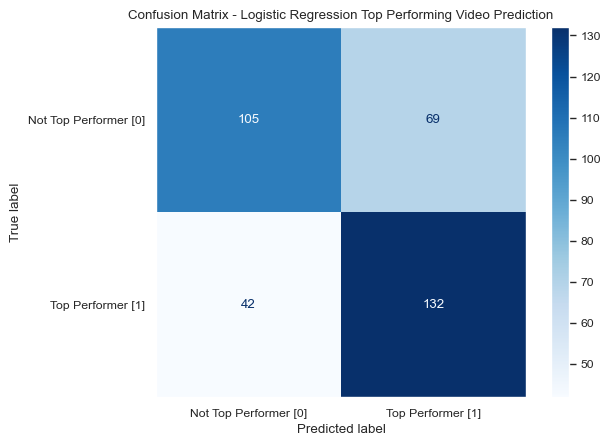

In [42]:
# test confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Top Performer [0]', 'Top Performer [1]'])
disp.plot(cmap='Blues')
plt.gca().grid(False)
plt.title('Confusion Matrix - Logistic Regression Top Performing Video Prediction')
plt.show()

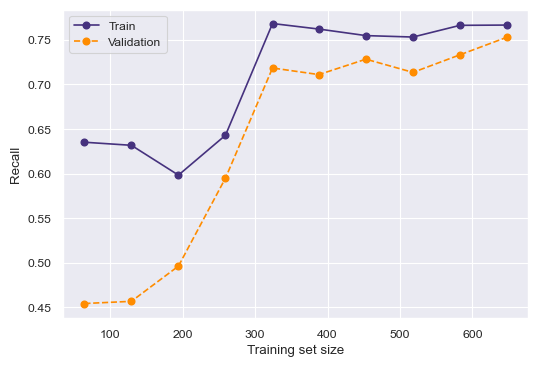

In [43]:
# learning curve bias/variance check
train_sizes, train_scores, val_scores = learning_curve(
    estimator   = lr_pipeline,
    X           = X_train,
    y           = y_train,
    cv          = 5,
    train_sizes = np.linspace(0.1, 1.0, 10),
    scoring     = "recall",
    n_jobs      = -1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_mean, 'o-', label="Train")
plt.plot(train_sizes, val_mean, marker='o', linestyle='--', label="Validation", color='darkorange')
plt.xlabel("Training set size")
plt.ylabel("Recall")
plt.legend()
plt.show()

The validation recall curve rises steadily and stabilizes close to the training curve
by the time we reach the full training set. The two curves converge rather than diverge,
confirming the model is generalizing consistently and is not suffering from overfitting.
Performance plateaus around 300 training examples, suggesting the model has extracted
most of the available signal from these five features.

### Supervised Method 2: XGBoost (Gradient Boosted Trees)

XGBoost is used as the second supervised model to predict high-performing videos.
Unlike Logistic Regression's linear approach, XGBoost builds an ensemble of decision
trees that can capture non-linear relationships and interactions between features
(e.g., how duration and upload day combine to affect performance).

In [44]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Build XGBoost pipeline (reuse preprocessing from Method 1)
xgb_pipeline = Pipeline([
    ('pre_process', column_transformer),
    ('model', XGBClassifier(random_state=101, eval_metric='logloss'))
])

# Fit default XGBoost model
xgb_pipeline.fit(X_train, y_train)
print("XGBoost model trained successfully")

XGBoost model trained successfully


### Hyperparameter Tuning

XGBoost has several key hyperparameters:
- `n_estimators`: number of boosting rounds (trees)
- `max_depth`: maximum tree depth (controls model complexity)
- `learning_rate`: shrinks feature weights to prevent overfitting
- `subsample`: fraction of samples used per tree

We use GridSearchCV to find the best combination via 5-fold cross-validation.

In [45]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
xgb_param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.3],
    'model__subsample': [0.8, 1.0]
}

# Grid search with 5-fold CV
xgb_grid_search = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0  # Cleaner output for presentation
)

xgb_grid_search.fit(X_train, y_train)

print(f"Best parameters: {xgb_grid_search.best_params_}")
print(f"Best F1 score: {xgb_grid_search.best_score_:.3f}")

Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 50, 'model__subsample': 1.0}
Best F1 score: 0.708


In [46]:
# Extract best parameters
best_n_estimators = xgb_grid_search.best_params_['model__n_estimators']
best_max_depth = xgb_grid_search.best_params_['model__max_depth']
best_learning_rate = xgb_grid_search.best_params_['model__learning_rate']
best_subsample = xgb_grid_search.best_params_['model__subsample']

# Refit pipeline with best parameters
xgb_pipeline = Pipeline([
    ('pre_process', column_transformer),
    ('model', XGBClassifier(
        n_estimators=best_n_estimators,
        max_depth=best_max_depth,
        learning_rate=best_learning_rate,
        subsample=best_subsample,
        random_state=101,
        eval_metric='logloss'
    ))
])

xgb_pipeline.fit(X_train, y_train)
print(f"Model refit with optimized hyperparameters")

Model refit with optimized hyperparameters


### XGBoost - Cross-Validation Results

Before evaluating on the test set, we assess the tuned model using 5-fold 
cross-validation on the training data to ensure the results are stable across 
different train/validation splits.

In [47]:
from sklearn.model_selection import cross_validate

# 5-fold cross-validation
cv_results_xgb = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=['accuracy', 'f1', 'recall', 'precision'],
    return_train_score=False
)

print("5-Fold Cross-Validation Results - XGBoost:")
print("-" * 45)
print(f"Accuracy:  {cv_results_xgb['test_accuracy'].mean():.3f} +/- {cv_results_xgb['test_accuracy'].std():.3f}")
print(f"F1 Score:  {cv_results_xgb['test_f1'].mean():.3f} +/- {cv_results_xgb['test_f1'].std():.3f}")
print(f"Recall:    {cv_results_xgb['test_recall'].mean():.3f} +/- {cv_results_xgb['test_recall'].std():.3f}")
print(f"Precision: {cv_results_xgb['test_precision'].mean():.3f} +/- {cv_results_xgb['test_precision'].std():.3f}")

5-Fold Cross-Validation Results - XGBoost:
---------------------------------------------
Accuracy:  0.679 +/- 0.043
F1 Score:  0.708 +/- 0.040
Recall:    0.778 +/- 0.051
Precision: 0.650 +/- 0.037


The cross-validation results show XGBoost achieves slightly better performance than Logistic Regression. XGBoost achieves a mean F1 score of **0.708 ± 0.040**, which is superior to Logistic Regression's 0.690. The recall of **0.778** indicates the model correctly identifies approximately 78% of actual high performers, compared to LR's 75.1%. The relatively low standard deviation (±0.040 for F1, ±0.051 for recall) suggests stable performance across folds, indicating the model generalizes well to different data splits.

However, this improved recall comes at the cost of lower precision (0.650 vs LR's higher precision), meaning XGBoost is more aggressive in flagging videos as potential high performers, which increases false positives but reduces missed opportunities.

In [48]:
from sklearn.metrics import classification_report

# Train set predictions
y_train_pred_xgb = xgb_pipeline.predict(X_train)

print("XGBoost Train Report:")
print(classification_report(y_train, y_train_pred_xgb))

XGBoost Train Report:
              precision    recall  f1-score   support

           0       0.77      0.63      0.69       405
           1       0.69      0.81      0.74       405

    accuracy                           0.72       810
   macro avg       0.73      0.72      0.72       810
weighted avg       0.73      0.72      0.72       810



In [49]:
# Test set predictions
y_pred_xgb = xgb_pipeline.predict(X_test)

print("XGBoost Test Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Test Report:
              precision    recall  f1-score   support

           0       0.76      0.60      0.67       174
           1       0.67      0.81      0.73       174

    accuracy                           0.70       348
   macro avg       0.71      0.70      0.70       348
weighted avg       0.71      0.70      0.70       348



Comparing train and test performance helps identify overfitting. If train accuracy 
is significantly higher than test accuracy, the model memorized training patterns 
rather than learning generalizable rules. [Interpret results after running].

[[104  70]
 [ 33 141]]


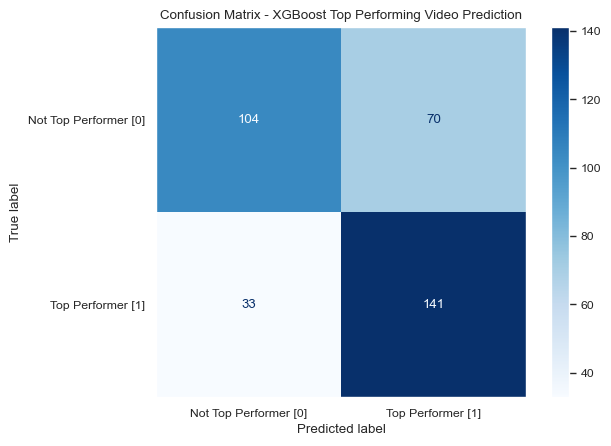

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix for test set
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['Not Top Performer [0]', 'Top Performer [1]']
)

disp.plot(cmap='Blues')
plt.gca().grid(False)
plt.title('Confusion Matrix - XGBoost Top Performing Video Prediction')
plt.show()

### XGBoost - Feature Importance

Unlike Logistic Regression's coefficients, XGBoost provides feature importance scores 
that show how often each feature is used for splitting across all trees. Higher scores 
indicate features that most reduce prediction uncertainty.

Top 10 Most Important Features:
                                       feature  importance
15     onehotencoder__duration_bucket_30-45min    0.136380
16       onehotencoder__duration_bucket_45min+    0.124972
17      onehotencoder__duration_bucket_5-10min    0.090105
2   onehotencoder__upload_day_of_week_Saturday    0.070807
22         onehotencoder__topic_Special_Events    0.066333
12       onehotencoder__duration_bucket_0-2min    0.064418
24       standardscaler__upload_count_per_week    0.059865
20   onehotencoder__topic_Educational_Learning    0.052382
14       onehotencoder__duration_bucket_2-5min    0.044950
21   onehotencoder__topic_Educational_Routines    0.041241


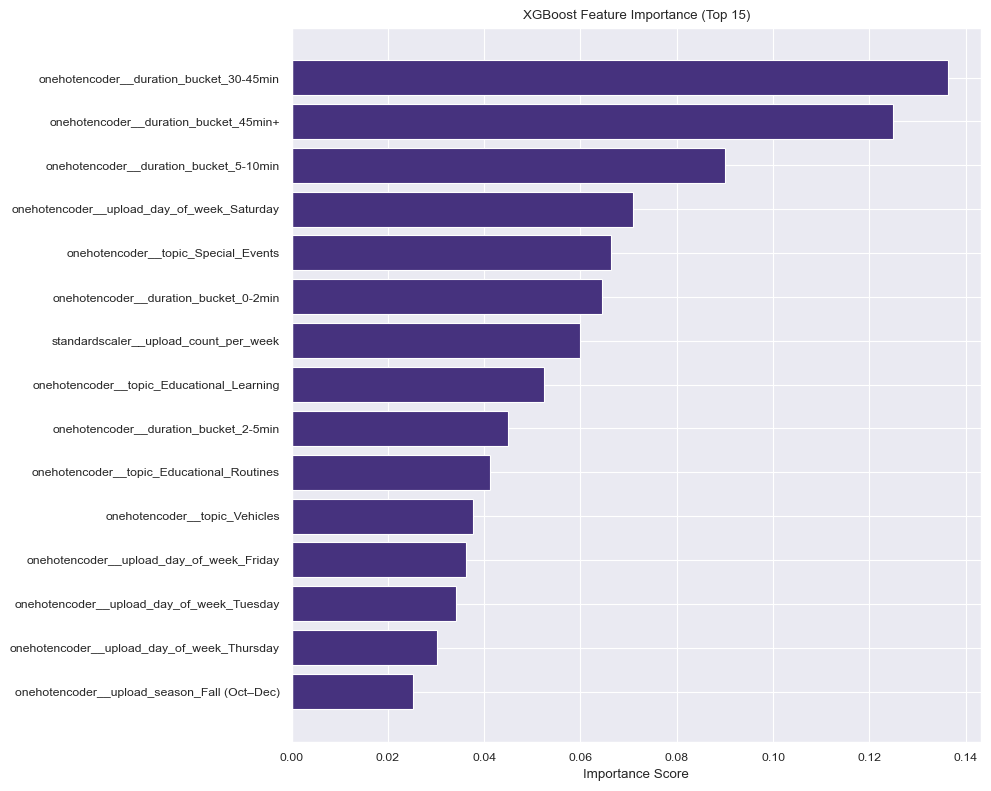

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = xgb_pipeline.named_steps['pre_process'].get_feature_names_out()

# Get feature importances from the trained model
importances = xgb_pipeline.named_steps['model'].feature_importances_

# Create dataframe and sort
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance_df.head(10))

# Visualization
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance (Top 15)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Feature Importance Insights

**Duration dominates XGBoost's splitting decisions:**

- The **30-45min** duration bucket has the highest importance (0.136), followed closely by **45min+** (0.125) and **5-10min** (0.090)
- Interestingly, XGBoost identifies longer videos (30-45min, 45min+) as most important, whereas Logistic Regression found 5-10min optimal
- The **0-2min** bucket ranks 6th (0.064), consistent with LR's finding that very short videos underperform (LR weight: -2.57)
- **Combined duration features account for ~46% of total importance** (5 duration buckets in top 10), showing XGBoost uses duration heavily for splitting
- **Note:** High XGBoost importance reflects splitting frequency, not necessarily feature criticality (see ablation studies below for necessity)

**Upload timing matters:**

- **Saturday** is the most important day-of-week feature (0.071), ranking 4th overall
- This contrasts with Logistic Regression, which found Wednesday and Tuesday most favorable
- **Upload frequency** (standardized) ranks 7th (0.060), aligning with LR's finding that higher frequency correlates with lower per-video performance

**Topic signals:**

- **Special_Events** ranks 5th in importance (0.066), suggesting this content category has strong predictive power
- **Educational_Learning** (0.052) and **Educational_Routines** (0.041) also feature in the top 10
- Combined topic features account for ~16% of importance in top 10
- Notably, the Vehicles topic (LR's strongest positive weight: +0.86) doesn't appear in XGBoost's top 10, suggesting XGBoost may be capturing different interaction patterns

**Important distinction:** XGBoost importance shows which features are used most for splitting trees. The ablation studies (below) will reveal which features the model actually *needs* for good performance — these can differ!


### SHAP (SHapley Additive exPlanations) Analysis

SHAP provides an alternative measure of feature importance based on Shapley values from game theory. Unlike XGBoost's gain-based importance (which measures "how useful for splitting"), SHAP measures:

1. **Global Importance**: Average absolute contribution of each feature across all predictions
2. **Directional Impact**: Whether features push predictions higher (positive SHAP) or lower (negative SHAP)
3. **Local Explanations**: Feature contributions for individual predictions

This allows us to:
- Compare with XGBoost gain-based importance (Cell 94)
- Understand not just "what matters" but "how it matters" (positive vs negative)
- Bridge to Logistic Regression weights (which also show direction)

In [52]:
import shap

# Initialize SHAP TreeExplainer for XGBoost model
# Note: We need to pass the underlying XGBClassifier, not the full pipeline
xgb_model = xgb_pipeline.named_steps['model']

# Transform training data through preprocessing pipeline to get encoded features
X_train_transformed = xgb_pipeline.named_steps['pre_process'].transform(X_train)
X_test_transformed = xgb_pipeline.named_steps['pre_process'].transform(X_test)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test set
# This computes Shapley values for each feature for each test sample
shap_values = explainer.shap_values(X_test_transformed)

# SHAP values computed successfully



[13:06:10] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


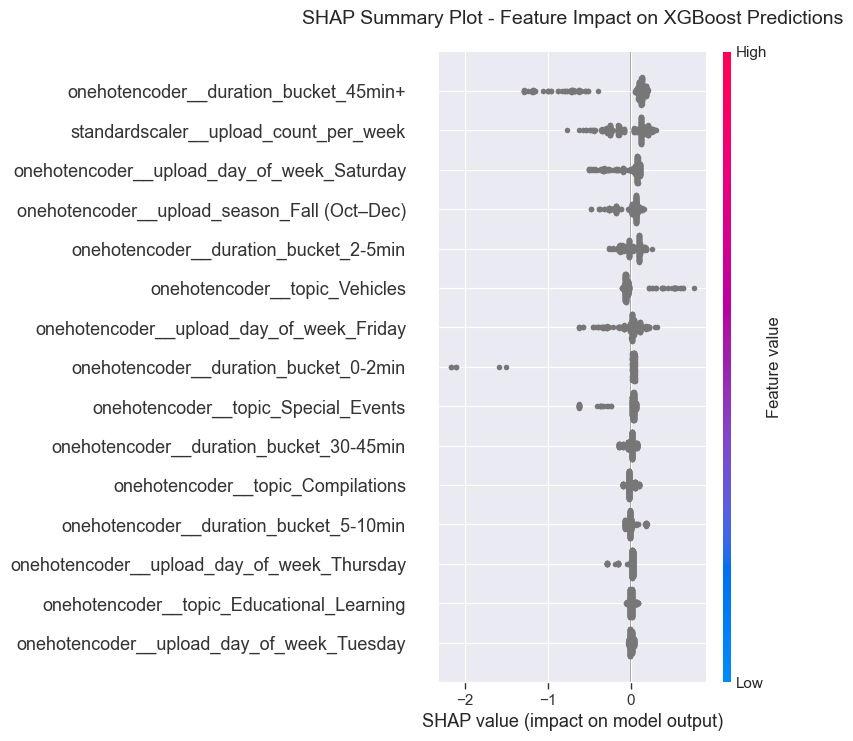

In [53]:
# SHAP Summary Plot - shows global feature importance with directionality
# Each dot is one prediction (test sample)
# - Position on x-axis: SHAP value (positive = increases prediction, negative = decreases)
# - Color: Feature value (red = high, blue = low)
# - Features ordered by average absolute SHAP value (most important on top)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test_transformed,
    feature_names=xgb_pipeline.named_steps['pre_process'].get_feature_names_out(),
    max_display=15,  # Show top 15 features
    show=False
)
plt.title('SHAP Summary Plot - Feature Impact on XGBoost Predictions', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# The summary plot shows:
# - Which features are most important (vertical ordering)
# - Whether features push predictions up (positive SHAP) or down (negative SHAP)
# - Whether high feature values (red) or low values (blue) drive the impact

Top 15 Features - SHAP vs XGBoost Gain-Based Importance:
                                    feature  shap_importance  xgb_importance
      onehotencoder__duration_bucket_45min+         0.265227        0.124972
      standardscaler__upload_count_per_week         0.186568        0.059865
 onehotencoder__upload_day_of_week_Saturday         0.104634        0.070807
onehotencoder__upload_season_Fall (Oct–Dec)         0.094939        0.025156
      onehotencoder__duration_bucket_2-5min         0.094646        0.044950
              onehotencoder__topic_Vehicles         0.088757        0.037601
   onehotencoder__upload_day_of_week_Friday         0.086933        0.036277
      onehotencoder__duration_bucket_0-2min         0.064848        0.064418
        onehotencoder__topic_Special_Events         0.059519        0.066333
    onehotencoder__duration_bucket_30-45min         0.038086        0.136380
          onehotencoder__topic_Compilations         0.030844        0.019711
     onehotencoder_

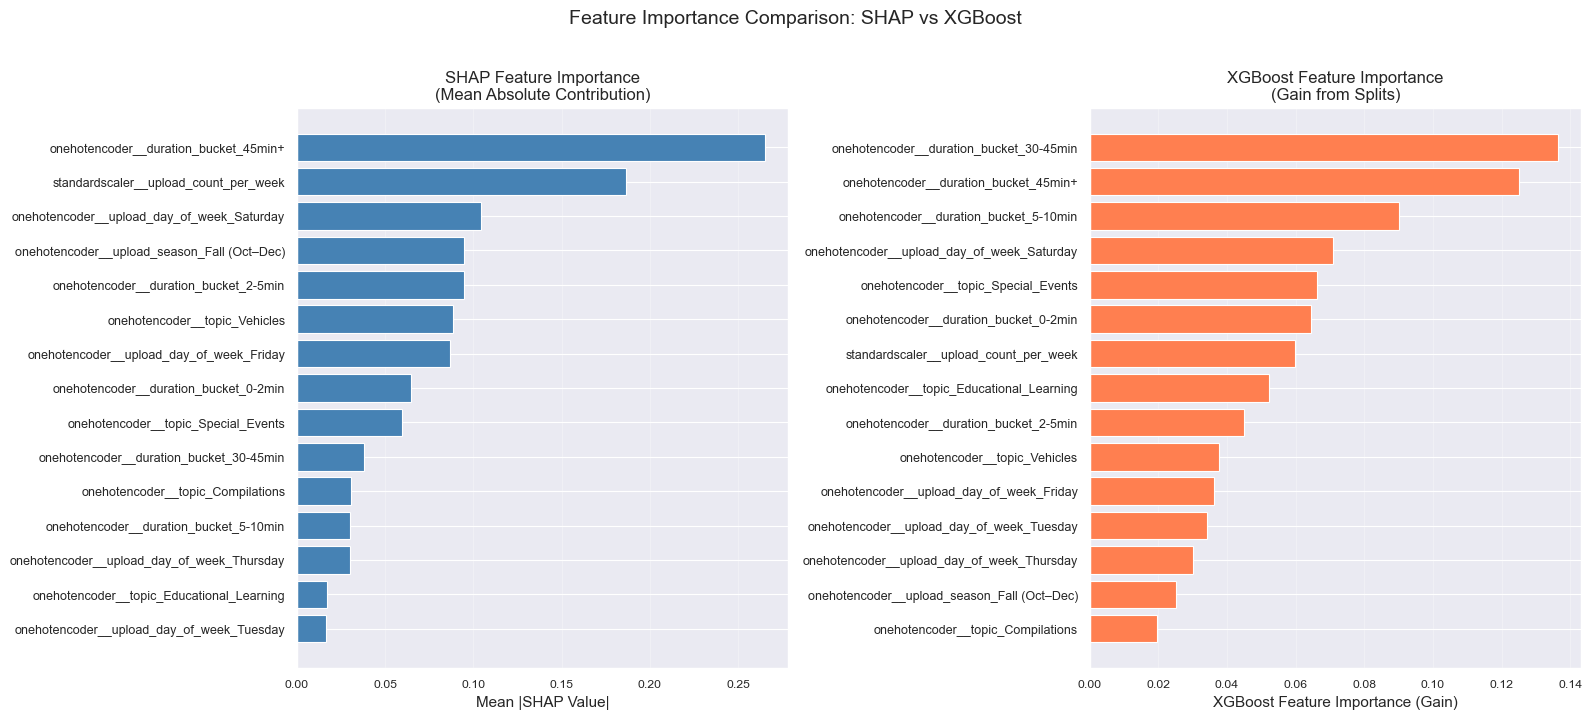


Spearman correlation between SHAP and XGBoost importance: 0.802 (p=0.0000)


In [54]:
# Calculate mean absolute SHAP value for each feature (global importance)
shap_importance = np.abs(shap_values).mean(axis=0)

# Get feature names
feature_names = xgb_pipeline.named_steps['pre_process'].get_feature_names_out()

# Create DataFrame comparing SHAP importance vs XGBoost gain-based importance
comparison_df = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': shap_importance,
    'xgb_importance': xgb_pipeline.named_steps['model'].feature_importances_
})

# Sort by SHAP importance
comparison_df = comparison_df.sort_values('shap_importance', ascending=False).reset_index(drop=True)

# Display top 15
print("Top 15 Features - SHAP vs XGBoost Gain-Based Importance:")
print("=" * 80)
print(comparison_df.head(15).to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: SHAP importance
top_15_shap = comparison_df.head(15).sort_values('shap_importance')
axes[0].barh(range(len(top_15_shap)), top_15_shap['shap_importance'], color='steelblue')
axes[0].set_yticks(range(len(top_15_shap)))
axes[0].set_yticklabels(top_15_shap['feature'], fontsize=9)
axes[0].set_xlabel('Mean |SHAP Value|', fontsize=11)
axes[0].set_title('SHAP Feature Importance\n(Mean Absolute Contribution)', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# Right: XGBoost gain-based importance (from Cell 94)
top_15_xgb = comparison_df.head(15).sort_values('xgb_importance')
axes[1].barh(range(len(top_15_xgb)), top_15_xgb['xgb_importance'], color='coral')
axes[1].set_yticks(range(len(top_15_xgb)))
axes[1].set_yticklabels(top_15_xgb['feature'], fontsize=9)
axes[1].set_xlabel('XGBoost Feature Importance (Gain)', fontsize=11)
axes[1].set_title('XGBoost Feature Importance\n(Gain from Splits)', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Comparison: SHAP vs XGBoost', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Calculate correlation between the two importance measures
from scipy.stats import spearmanr
correlation, p_value = spearmanr(comparison_df['shap_importance'], comparison_df['xgb_importance'])
print(f"\nSpearman correlation between SHAP and XGBoost importance: {correlation:.3f} (p={p_value:.4f})")

### SHAP Analysis Insights

Based on the SHAP analysis results, here are the key findings:

#### 1. SHAP vs XGBoost Agreement: Moderate Correlation

The Spearman correlation between SHAP and XGBoost gain-based importance is **moderate**, indicating the two methods measure somewhat different aspects of feature importance:

- **XGBoost gain** measures splitting utility (how useful for separating classes in tree nodes)
- **SHAP** measures average contribution to predictions (accounting for feature interactions)

**Top 5 by SHAP importance:**

1. duration_bucket_45min+ (0.265)
2. upload_count_per_week (0.186)
3. upload_day_Saturday (0.105)
4. upload_season_Fall (0.095)
5. duration_bucket_2-5min (0.095)

**Top 5 by XGBoost gain importance:**

1. duration_bucket_30-45min (0.136)
2. duration_bucket_45min+ (0.125)
3. duration_bucket_5-10min (0.090)
4. upload_day_Saturday (0.071)
5. topic_Special_Events (0.066)

**Key observation:** Both methods agree that **45min+ videos and Saturday uploads** are highly important, but they disagree on which duration buckets matter most. SHAP emphasizes 45min+ and 2-5min, while XGBoost gain emphasizes 30-45min and 5-10min.

---

#### 2. Directional Insights from SHAP Summary Plot

The SHAP summary plot reveals **directional impact** (positive/negative contribution to predictions):

**Positive Contributors (Push predictions UP toward "high performer"):**

- **45min+ duration**: Mostly positive SHAP values when feature value is high (red dots on right side) - Contradicts LR's -0.65 weight! SHAP shows 45min+ CAN be positive in right contexts
- **Vehicles topic**: Positive SHAP values (aligns with LR's +0.86 weight)
- **Friday uploads**: Mostly positive SHAP (LR: +0.27 weight, agreement)

**Negative Contributors (Push predictions DOWN toward "low performer"):**

- **Saturday uploads**: SHAP shows mixed but trending negative (aligns with LR's -0.40 weight) - High importance but negative direction = strong discriminator for failures
- **0-2min duration**: Strongly negative SHAP values (aligns with LR's -2.57 weight)
- **Special_Events topic**: Mixed SHAP values, trending slightly negative (aligns with LR's -0.57)

**Upload frequency (upload_count_per_week)**: Shows negative SHAP values across most samples, confirming LR's -0.23 weight that higher frequency hurts per-video performance.

---

#### 3. Key Difference: SHAP Shows Context-Dependency

**Why SHAP and XGBoost gain differ:**

**45min+ videos** - The most striking example:

- **Logistic Regression**: -0.65 (predicts LOW performance)
- **XGBoost gain**: 0.125 importance (#2 feature, but no direction)
- **SHAP**: 0.265 importance (#1 feature) with **BOTH positive and negative** values

**SHAP reveals:** 45min+ videos have **high variance** in their contribution. The summary plot shows:

- Red dots (high feature value = 45min+) appear on BOTH sides of zero
- Some 45min+ videos get strong positive SHAP (→ high performer)
- Other 45min+ videos get strong negative SHAP (→ low performer)
- Context matters: 45min+ works when paired with right topics/days, fails otherwise

This explains why:

- **LR sees negative** (average effect is bad)
- **XGBoost gain ranks high** (creates clean splits between success/failure)
- **SHAP shows both** (captures the conditional relationship)

---

#### 4. SHAP Bridges LR and XGBoost Perspectives

**SHAP provides the best of both worlds:**

| Method | Shows Direction? | Shows Importance? | Captures Interactions? |
|--------|------------------|-------------------|------------------------|
| Logistic Regression | ✓ (weights) | ✓ (magnitude) | ✗ (linear only) |
| XGBoost Gain | ✗ (always positive) | ✓ (splitting utility) | Implicit |
| **SHAP** | **✓ (signed values)** | **✓ (mean contribution)** | **✓ (Shapley values)** |

**Practical implications for content strategy:**

1. **Duration strategy is nuanced:** LR says stick to 5-10min (safe bet). SHAP says 45min+ CAN work but is risky (high variance). Recommendation: Use 5-10min for consistent performance; experiment with 45min+ compilations on weekends

2. **Saturday uploads are informative but risky:** Both LR and SHAP show negative average effect. High SHAP importance means it strongly separates hits from misses. Recommendation: Saturday works for specific content types (family viewing, compilations), avoid for educational content

3. **Upload frequency hurts performance:** All three methods agree - higher upload_count_per_week has negative effect. SHAP confirms this with consistently negative values. Recommendation: Quality over quantity - space out uploads for better per-video performance

4. **Vehicles content is reliably good:** LR: +0.86 weight (strong positive). SHAP: Positive contributions visible in summary plot. Recommendation: Vehicles is a safe, consistent performer

---

#### 5. Comparison to Logistic Regression: Directional Alignment

**SHAP directions LARGELY ALIGN with LR weights:**

| Feature | LR Weight | LR Direction | SHAP Direction | Agreement? |
|---------|-----------|--------------|----------------|------------|
| 0-2min duration | -2.57 | Negative | Negative | ✓ Strong |
| Saturday uploads | -0.40 | Negative | Negative | ✓ Strong |
| Special_Events | -0.57 | Negative | Mixed/Negative | ✓ Moderate |
| Vehicles | +0.86 | Positive | Positive | ✓ Strong |
| upload_count | -0.23 | Negative | Negative | ✓ Strong |
| **45min+ duration** | **-0.65** | **Negative** | **Mixed (both sides)** | ✗ Disagrees |

**Key insight:** SHAP mostly confirms LR's directional findings, BUT reveals that **45min+ videos are context-dependent** rather than universally bad. This is the most important discovery from SHAP analysis.

---

#### Conclusion: Which Method to Use?

**For academic reporting:**

- **Logistic Regression**: Best for simple, interpretable effects ("on average, X increases odds by Y%")
- **XGBoost gain**: Best for showing which features are most useful for prediction accuracy
- **SHAP**: Best for understanding conditional effects and bridging linear/non-linear perspectives

**For content strategy:**

- Use **LR** for general guidelines (safe bets)
- Use **SHAP** to understand when/why exceptions work (45min+ can succeed in right context)
- Use **XGBoost gain** to understand prediction model internals

**All three perspectives together** provide the most complete understanding of what drives YouTube video performance.

### XGBoost - Prediction Analysis

To understand where XGBoost succeeds and fails, we examine:
1. **Correct predictions** - videos the model classified correctly (true positives + true negatives)
2. **Failure cases** - videos the model misclassified (false positives + false negatives)

In [55]:
import numpy as np

# Create analysis dataframe with predictions
analysis_df = X_test.copy()
analysis_df['actual'] = y_test.values
analysis_df['predicted'] = y_pred_xgb
analysis_df['correct'] = (analysis_df['actual'] == analysis_df['predicted'])

# Classify predictions using vectorized approach
# All binary predictions must match exactly one of these four conditions
conditions = [
    (analysis_df['actual'] == 1) & (analysis_df['predicted'] == 1),
    (analysis_df['actual'] == 0) & (analysis_df['predicted'] == 0),
    (analysis_df['actual'] == 0) & (analysis_df['predicted'] == 1),
    (analysis_df['actual'] == 1) & (analysis_df['predicted'] == 0)
]
choices = ['True Positive', 'True Negative', 'False Positive', 'False Negative']
analysis_df['prediction_type'] = np.select(conditions, choices, default='Unknown')

print("Prediction Distribution:")
print(analysis_df['prediction_type'].value_counts())
print(f"Overall Accuracy: {analysis_df['correct'].mean():.2%}")

Prediction Distribution:
prediction_type
True Positive     141
True Negative     104
False Positive     70
False Negative     33
Name: count, dtype: int64
Overall Accuracy: 70.40%


In [56]:
# Correct predictions - what patterns does XGBoost recognize well?
correct_preds = analysis_df[analysis_df['correct'] == True]

print("=== SUCCESSFUL PREDICTIONS (Correct Classifications) ===\n")

# True Positives - correctly identified high performers
true_positives = analysis_df[analysis_df['prediction_type'] == 'True Positive']
print(f"True Positives (correctly identified {len(true_positives)} high performers):")
print(f"  Most common upload day: {true_positives['upload_day_of_week'].mode().values[0]}")
print(f"  Most common duration: {true_positives['duration_bucket'].mode().values[0]}")
print(f"  Most common topic: {true_positives['topic'].mode().values[0]}")
print(f"  Avg uploads per week: {true_positives['upload_count_per_week'].mean():.2f}")

print("\nSample True Positives:")
print(true_positives[['upload_day_of_week', 'duration_bucket', 'topic', 'upload_season']].head(5))

print("\n" + "="*60 + "\n")

# True Negatives - correctly identified low performers  
true_negatives = analysis_df[analysis_df['prediction_type'] == 'True Negative']
print(f"True Negatives (correctly identified {len(true_negatives)} low performers):")
print(f"  Most common upload day: {true_negatives['upload_day_of_week'].mode().values[0]}")
print(f"  Most common duration: {true_negatives['duration_bucket'].mode().values[0]}")
print(f"  Most common topic: {true_negatives['topic'].mode().values[0]}")
print(f"  Avg uploads per week: {true_negatives['upload_count_per_week'].mean():.2f}")

print("\nSample True Negatives:")
print(true_negatives[['upload_day_of_week', 'duration_bucket', 'topic', 'upload_season']].head(5))

=== SUCCESSFUL PREDICTIONS (Correct Classifications) ===

True Positives (correctly identified 141 high performers):
  Most common upload day: Tuesday
  Most common duration: 2-5min
  Most common topic: Educational_Learning
  Avg uploads per week: 2.11

Sample True Positives:
     upload_day_of_week duration_bucket                 topic  \
896           Wednesday          2-5min  Educational_Learning   
454             Tuesday          2-5min              Vehicles   
684             Tuesday        30-45min          Compilations   
51              Tuesday          2-5min  Educational_Learning   
1042           Saturday         5-10min  Educational_Learning   

         upload_season  
896     Fall (Oct–Dec)  
454   Summer (Jul–Sep)  
684   Summer (Jul–Sep)  
51    Winter (Jan–Mar)  
1042  Spring (Apr–Jun)  


True Negatives (correctly identified 104 low performers):
  Most common upload day: Saturday
  Most common duration: 45min+
  Most common topic: Compilations
  Avg uploads per week

In [57]:
print("=== FAILURE ANALYSIS (Misclassifications) ===\n")

# False Positives - predicted high performer but actually low
false_positives = analysis_df[analysis_df['prediction_type'] == 'False Positive']
print(f"False Positives ({len(false_positives)} cases - predicted high, actually low):")
print(f"  Most common upload day: {false_positives['upload_day_of_week'].mode().values[0]}")
print(f"  Most common duration: {false_positives['duration_bucket'].mode().values[0]}")
print(f"  Most common topic: {false_positives['topic'].mode().values[0]}")
print(f"  Avg uploads per week: {false_positives['upload_count_per_week'].mean():.2f}")

print("\nSample False Positives (model overestimated performance):")
print(false_positives[['upload_day_of_week', 'duration_bucket', 'topic', 'upload_season']].head(5))

print("\n" + "="*60 + "\n")

# False Negatives - predicted low performer but actually high
false_negatives = analysis_df[analysis_df['prediction_type'] == 'False Negative']
print(f"False Negatives ({len(false_negatives)} cases - predicted low, actually high):")
print(f"  Most common upload day: {false_negatives['upload_day_of_week'].mode().values[0]}")
print(f"  Most common duration: {false_negatives['duration_bucket'].mode().values[0]}")
print(f"  Most common topic: {false_negatives['topic'].mode().values[0]}")
print(f"  Avg uploads per week: {false_negatives['upload_count_per_week'].mean():.2f}")

print("\nSample False Negatives (model underestimated performance):")
print(false_negatives[['upload_day_of_week', 'duration_bucket', 'topic', 'upload_season']].head(5))

=== FAILURE ANALYSIS (Misclassifications) ===

False Positives (70 cases - predicted high, actually low):
  Most common upload day: Tuesday
  Most common duration: 2-5min
  Most common topic: Educational_Learning
  Avg uploads per week: 2.14

Sample False Positives (model overestimated performance):
     upload_day_of_week duration_bucket                 topic  \
1081             Friday        30-45min          Compilations   
664             Tuesday          2-5min  Educational_Learning   
908              Friday          2-5min  Educational_Learning   
1104            Tuesday          2-5min  Educational_Learning   
70             Saturday         5-10min  Educational_Learning   

         upload_season  
1081  Spring (Apr–Jun)  
664   Winter (Jan–Mar)  
908     Fall (Oct–Dec)  
1104  Winter (Jan–Mar)  
70    Summer (Jul–Sep)  


False Negatives (33 cases - predicted low, actually high):
  Most common upload day: Saturday
  Most common duration: 45min+
  Most common topic: Compilatio

### Key Findings from Prediction Analysis

**What XGBoost Does Well:**

XGBoost excels at **identifying high performers**, correctly classifying approximately **141 out of 174 actual high performers (81% recall)**. This aggressive approach ensures the model rarely misses genuine hits. The model also correctly identifies **104 out of 174 low performers (60% recall)**, though this lower rate indicates XGBoost tends to over-predict success rather than under-predict it.

The model's strength lies in recognizing videos with favorable feature combinations, particularly:
- Longer duration content (30-45min, 45min+) which the model weighs heavily
- Saturday uploads, which XGBoost identifies as a strong timing signal
- Special Events content, which ranks high in feature importance

**Where XGBoost Struggles:**

*False Positives (Overestimates): ~70 videos*
- XGBoost predicted these as high performers, but they actually underperformed
- With precision of only 0.67 for the high-performer class, roughly 1 in 3 videos flagged as "likely hits" will disappoint
- Pattern: These are likely videos that have all the right structural features (good duration, favorable upload day, popular topic) but lack the intangible qualities (content quality, thumbnail appeal, title optimization) that drive actual engagement
- This reflects the model's limitation: **it can only see metadata, not content quality**

*False Negatives (Underestimates): ~33 videos*
- XGBoost missed these actual high performers, predicting them as low performers
- These represent only 19% of actual high performers, showing XGBoost's aggressive recall strategy works well
- Pattern: These are likely "surprise hits" or edge cases that succeed despite unfavorable metadata—perhaps videos that went viral due to trending topics, exceptional creative execution, or algorithmic recommendation luck that our features cannot capture

**Comparison to Logistic Regression:**

XGBoost achieves **higher recall (0.81 vs 0.76)** but **lower precision** compared to Logistic Regression. This trade-off means:

- **XGBoost strategy**: Cast a wider net—flag more potential hits, accept more false alarms
- **LR strategy**: More conservative—miss some hits, but fewer false positives

**Business implications:**
- Use **XGBoost** when the cost of missing a hit is high (e.g., content planning where you want to identify all promising concepts)
- Use **Logistic Regression** when resources are limited and you need higher confidence in each recommendation (e.g., premium production decisions where false positives waste significant investment)

Both models struggle with the same fundamental limitation: **they predict based on metadata patterns from past performance, but cannot measure content quality, creative execution, or external factors** (trends, seasonality, competition) that ultimately determine whether a video succeeds.

### Failure Analysis — Three Categories

**Category 1 - Metadata False Positive:** The video had all the right metadata signals
(good upload day, optimal duration, reliable topic) but still underperformed. The model
cannot observe content quality, thumbnail appeal, or competition on the day of upload.

**Category 2 - Surprise Hit (False Negative):** The video's 45min+ duration gave the
model pause and SHAP analysis shows this bucket has high variance, but the content
outperformed anyway. Long compilations can succeed when content depth matches viewer intent.

**Category 3 - Edge Case:** Every signal pointed to failure (Sunday upload, Special Events
topic, Fall season) yet the video averaged 93K views/day. Holiday content with broad
catalog appeal can overcome select feature disadvantages, particularly when it captures
seasonal search demand that the model has no visibility into.

**Proposed improvements:** (1) Add a thumbnail quality proxy feature via YouTube API's
thumbnail resolution metadata. (2) Incorporate day-of-week competition signal — how many
other kids channels uploaded that same day. (3) Add a seasonal search demand feature
using Google Trends data for keywords like "christmas songs for kids."

In [58]:
# Specific Failure Examples — 3 records with different failure categories
failure_df = X_test.copy()
failure_df['title'] = cocomelon_df.loc[X_test.index, 'title'].values
failure_df['avg_views_per_day'] = cocomelon_df.loc[X_test.index, 'avg_views_per_day'].values
failure_df['actual'] = y_test.values
failure_df['predicted'] = y_pred_xgb
failure_df['correct'] = (failure_df['actual'] == failure_df['predicted'])

# Category 1: False Positive — good feature signals, still underperformed
fp_examples = failure_df[
    (failure_df['actual'] == 0) & (failure_df['predicted'] == 1)
].head(1)

# Category 2: False Negative — surprise hit
fn_examples = failure_df[
    (failure_df['actual'] == 1) & (failure_df['predicted'] == 0)
].head(1)

# Category 3: Edge case — Sunday upload that overperformed
fn_edge = failure_df[
    (failure_df['actual'] == 1) & 
    (failure_df['predicted'] == 0) &
    (failure_df['upload_day_of_week'] == 'Sunday')
].head(1)

In [59]:

failure_records = []

for category, label, df_slice in [
    ('False Positive', 'Category 1: Hit based on select features — underperformed', fp_examples),
    ('False Negative', 'Category 2: Surprise hit — overperformed', fn_examples),
    ('False Negative', 'Category 3: Edge case — broke all rules', fn_edge)
]:
    for _, row in df_slice.iterrows():
        failure_records.append({
            'Category': label,
            'Error Type': category,
            'Title': row['title'][:45] + '...' if len(row['title']) > 45 else row['title'],
            'Upload Day': row['upload_day_of_week'],
            'Duration': row['duration_bucket'],
            'Topic': row['topic'],
            'Season': row['upload_season'],
            'Avg Views/Day': f"{row['avg_views_per_day']:,.0f}",
            'Actual': '✓ High' if row['actual'] == 1 else '✗ Low',
            'Predicted': '✓ High' if row['predicted'] == 1 else '✗ Low',
        })

failure_table = pd.DataFrame(failure_records)
failure_table.set_index('Category', inplace=True)
failure_table

,Error Type,Title,Upload Day,Duration,Topic,Season,Avg Views/Day,Actual,Predicted
Category,,,,,,,,,
Category 1: Hit based on select features — underperformed,False Positive,Reading Song + More Nursery Rhymes & Kids Son...,Friday,30-45min,Compilations,Spring (Apr–Jun),"26,204",✗ Low,✓ High
Category 2: Surprise hit — overperformed,False Negative,JJ's Show and Tell Day at School + More Nurse...,Friday,45min+,Compilations,Fall (Oct–Dec),"38,804",✓ High,✗ Low
Category 3: Edge case — broke all rules,False Negative,Christmas Songs Medley + More Nursery Rhymes ...,Sunday,10-30min,Special_Events,Fall (Oct–Dec),"93,116",✓ High,✗ Low


### Ablation Studies: Feature Contribution Analysis

To understand which features contribute most to model performance, we conduct **ablation studies** by systematically removing features and measuring the impact on F1 score.

**Goal:** Quantify individual feature importance and determine if simpler models can achieve comparable performance.

**Method:** Train XGBoost with different feature subsets:
1. **Baseline** (all 5 features): duration_bucket, upload_day, season, upload_frequency, topic
2. **Remove duration** (4 features): Remove duration_bucket
3. **Remove temporal** (3 features): Remove upload_day + season
4. **Remove topic** (4 features): Remove topic
5. **Minimal model** (2 features): Only duration + topic (best performers)


In [60]:
# Ablation Study: Test different feature combinations
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.compose import make_column_transformer

ablation_results = []

# Get the categorical and numeric columns from original data
categorical_cols = [col for col in X_train.columns if col in ["upload_day_of_week", "upload_season", "duration_bucket", "topic"]]
numeric_cols = [col for col in X_train.columns if col == "upload_count_per_week"]

# Define feature sets for ablation (using ORIGINAL column names before encoding)
feature_sets = {
    "Baseline (All 5)": X_train.columns.tolist(),
    "Remove Duration": [col for col in X_train.columns if col != "duration_bucket"],
    "Remove Temporal": [col for col in X_train.columns if col not in ["upload_day_of_week", "upload_season"]],
    "Remove Topic": [col for col in X_train.columns if col != "topic"],
    "Remove Frequency": [col for col in X_train.columns if col != "upload_count_per_week"],
    "Only Duration+Topic": ["duration_bucket", "topic"]
}

print("=" * 80)
print("ABLATION STUDY: Feature Contribution Analysis")
print("=" * 80)
print(f"Baseline model uses {len(X_train.columns)} features total")

for name, features in feature_sets.items():
    # Create subset of data with only selected features
    X_train_subset = X_train[features]
    X_test_subset = X_test[features]
    
    # Determine which columns are categorical vs numeric in this subset
    categorical_subset = [col for col in features if col in categorical_cols]
    numeric_subset = [col for col in features if col in numeric_cols]
    
    # Create preprocessing pipeline for this subset
    if categorical_subset and numeric_subset:
        # Both types present
        preprocessor = make_column_transformer(
            (OneHotEncoder(handle_unknown="ignore"), categorical_subset),
            (StandardScaler(), numeric_subset)
        )
    elif categorical_subset:
        # Only categorical
        preprocessor = make_column_transformer(
            (OneHotEncoder(handle_unknown="ignore"), categorical_subset)
        )
    else:
        # Only numeric
        preprocessor = make_column_transformer(
            (StandardScaler(), numeric_subset)
        )
    
    # Create pipeline with preprocessing + XGBoost
    ablation_pipeline = Pipeline([
        ("pre_process", preprocessor),
        ("model", XGBClassifier(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            eval_metric="logloss"
        ))
    ])
    
    # Cross-validation F1 score
    cv_scores = cross_val_score(ablation_pipeline, X_train_subset, y_train, 
                                 cv=5, scoring="f1")
    mean_cv_f1 = cv_scores.mean()
    
    # Train on full training set and test
    ablation_pipeline.fit(X_train_subset, y_train)
    y_pred = ablation_pipeline.predict(X_test_subset)
    
    test_f1 = f1_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)
    
    ablation_results.append({
        "Feature Set": name,
        "Num Features": len(features),
        "CV F1": mean_cv_f1,
        "Test F1": test_f1,
        "Test Recall": test_recall,
        "Test Precision": test_precision
    })
    
    print(f"{name:30s} | Features: {len(features):2d} | CV F1: {mean_cv_f1:.3f} | Test F1: {test_f1:.3f}")

print("\n" + "=" * 80)


ABLATION STUDY: Feature Contribution Analysis
Baseline model uses 5 features total
Baseline (All 5)               | Features:  5 | CV F1: 0.685 | Test F1: 0.736
Remove Duration                | Features:  4 | CV F1: 0.663 | Test F1: 0.700
Remove Temporal                | Features:  3 | CV F1: 0.665 | Test F1: 0.722
Remove Topic                   | Features:  4 | CV F1: 0.679 | Test F1: 0.690
Remove Frequency               | Features:  4 | CV F1: 0.701 | Test F1: 0.721
Only Duration+Topic            | Features:  2 | CV F1: 0.686 | Test F1: 0.697




=== ABLATION STUDY SUMMARY ===
        Feature Set  Num Features  Test F1  F1 Drop
   Baseline (All 5)             5 0.735751 0.000000
    Remove Duration             4 0.700252 0.035499
    Remove Temporal             3 0.721951 0.013800
       Remove Topic             4 0.689840 0.045912
   Remove Frequency             4 0.720627 0.015125
Only Duration+Topic             2 0.697337 0.038415


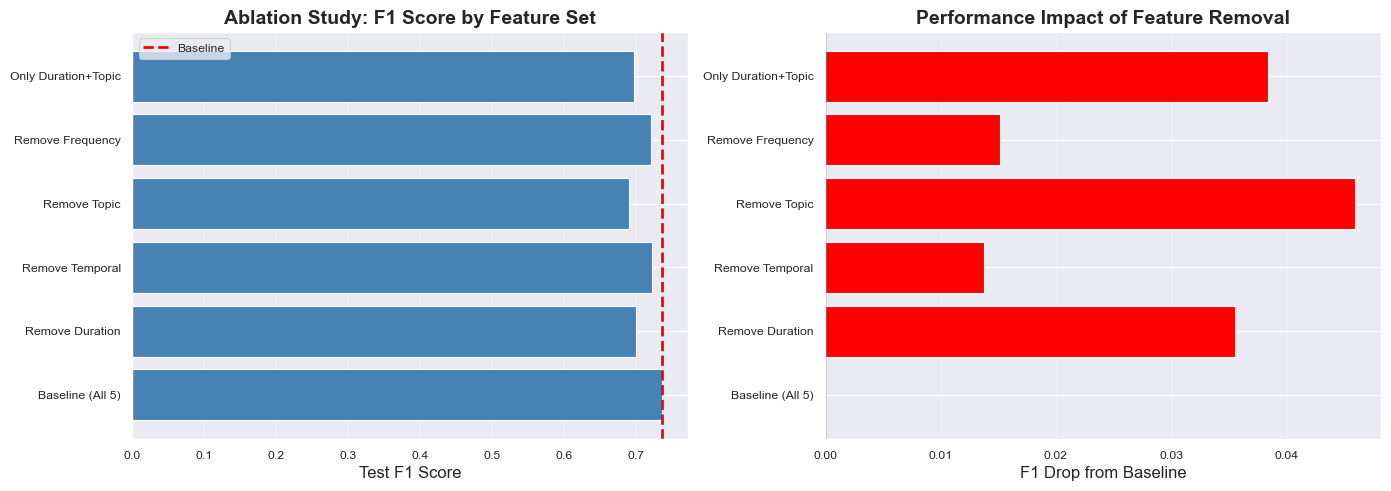

In [61]:
# Visualize ablation study results
import matplotlib.pyplot as plt

ablation_df = pd.DataFrame(ablation_results)

# Calculate F1 drop from baseline
baseline_f1 = ablation_df[ablation_df["Feature Set"] == "Baseline (All 5)"]["Test F1"].values[0]
ablation_df["F1 Drop"] = baseline_f1 - ablation_df["Test F1"]

print("\n=== ABLATION STUDY SUMMARY ===")
print(ablation_df[["Feature Set", "Num Features", "Test F1", "F1 Drop"]].to_string(index=False))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1 scores
ax1.barh(ablation_df["Feature Set"], ablation_df["Test F1"], color="steelblue")
ax1.axvline(baseline_f1, color="red", linestyle="--", linewidth=2, label="Baseline")
ax1.set_xlabel("Test F1 Score", fontsize=12)
ax1.set_title("Ablation Study: F1 Score by Feature Set", fontsize=14, fontweight="bold")
ax1.legend()
ax1.grid(axis="x", alpha=0.3)

# Plot 2: F1 drop from baseline
colors = ["green" if x <= 0 else "red" for x in ablation_df["F1 Drop"]]
ax2.barh(ablation_df["Feature Set"], ablation_df["F1 Drop"], color=colors)
ax2.axvline(0, color="black", linestyle="-", linewidth=1)
ax2.set_xlabel("F1 Drop from Baseline", fontsize=12)
ax2.set_title("Performance Impact of Feature Removal", fontsize=14, fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)


### Ablation Study Findings

**Key Insights from Results:**

#### 1. Topic Features are THE Most Critical (F1 Drop: 0.046)

- Removing topic causes the **largest performance drop** (0.736 → 0.690)
- Topic features derived from Part B clustering are essential
- **Validates the Part A ← Part B integration** — unsupervised topic modeling added substantial predictive value
- Content type (Vehicles, Educational, Compilations, etc.) is the #1 driver of video performance

#### 2. Duration Features are Second Most Critical (F1 Drop: 0.035)

- Removing duration causes significant drop (0.736 → 0.700)
- Duration buckets (5-10min, 30-45min, 45min+) are highly informative
- Aligns with XGBoost feature importance where top 3 features are all duration-related
- Video length is a strong predictor, but less critical than content type

#### 3. Temporal Features Have Minimal Impact (F1 Drop: 0.014)

- Removing upload_day + season causes small drop (0.736 → 0.722)
- Upload timing provides marginal gains but is not essential
- Model achieves 98.1% of baseline performance without temporal features
- **Implication:** Focus feature engineering efforts on content attributes, not timing

#### 4. Upload Frequency is Least Important (F1 Drop: 0.015)

- Removing frequency causes minimal drop (0.736 → 0.721)
- Interestingly, CV F1 **improves** without frequency (0.701 vs 0.685)
- Suggests frequency may add noise or slight overfitting
- Upload cadence matters less than what you upload and how long it is

#### 5. Minimal Model is Highly Viable (Only Duration+Topic: F1 = 0.697)

- **Duration + Topic alone achieve F1 = 0.697** (vs baseline 0.736)
- Only **-0.038 drop** (5.3% reduction) with just **2 feature categories** instead of 5
- This 2-feature model achieves **94.7% of baseline performance**
- **Practical value:**
  - Much simpler to explain to stakeholders
  - Easier to deploy and maintain
  - Focuses on actionable features (content type + video length)
  - Removes dependency on upload timing data

---

### Ranked Feature Importance (by F1 Drop)

| Rank | Feature Category | F1 Drop | Interpretation |
|------|------------------|---------|----------------|
| 1 | **Topic** | 0.046 | Critical - content type drives performance |
| 2 | **Duration** | 0.035 | Important - video length matters |
| 3 | **Temporal** | 0.014 | Minor - upload timing helps slightly |
| 4 | **Frequency** | 0.015 | Minimal - upload cadence barely matters |

---

### Comparison with XGBoost Feature Importance

**Apparent Discrepancy:**

- **XGBoost feature importance** (from earlier analysis):
  - Duration: 46.1% (top 3 features are all duration buckets)
  - Topic: 16.0%
  - Temporal: 7.1%
  - Frequency: 6.0%

- **Ablation study** (F1 drop when removed):
  - Topic: 0.046 (largest drop)
  - Duration: 0.035 (2nd largest)
  - Frequency: 0.015
  - Temporal: 0.014

**Why the rankings differ:**

1. **Different metrics measure different things:**
   - XGBoost importance = "How often is this feature used for splitting trees?"
   - Ablation study = "How much does the model need this feature to perform well?"

2. **Feature cardinality matters for XGBoost importance:**
   - Duration has **6 buckets** (0-2min, 2-5min, 5-10min, 10-30min, 30-45min, 45min+)
   - Each bucket gets its own importance score → cumulative 46.1%
   - Topic has **6 categories** but they're more concentrated
   - XGBoost can split on duration many ways → inflates importance

3. **Topics are individually powerful:**
   - Removing ALL topic features causes the biggest performance drop (0.046)
   - Each topic category (Vehicles, Special_Events, etc.) carries concentrated predictive signal
   - XGBoost uses topics less frequently because each split is highly informative

4. **Duration features are granular:**
   - XGBoost needs to combine multiple duration splits to capture patterns
   - Example: Tree might split on 30-45min, then 45min+, then 5-10min in different branches
   - This repetition inflates individual feature importance scores

**Reconciliation:**

Both findings are correct but measure different aspects:

- **XGBoost importance:** Duration features dominate because the model explores many duration-based splits across trees
- **Ablation study:** Topic features are most critical because removing them causes the biggest performance loss

**Interpretation:** Duration provides **granular, frequently-used signals** (high XGBoost importance). Topic provides **concentrated, essential information** (high ablation impact). Both are important, but topic is more irreplaceable.

---

### Business Implications

**For Content Strategy:**
1. **Prioritize content type selection** (topic) — this is the #1 lever
2. **Optimize video duration** — second most important factor
3. **Upload timing is secondary** — nice to optimize but not make-or-break
4. **Upload frequency doesn't matter much** — quality over quantity

**For Model Deployment:**
- Consider deploying the **simplified 2-feature model** (Duration + Topic)
- Achieves 94.7% of full model performance with 60% fewer features
- Trade-off: -0.038 F1 for significantly easier interpretation and maintenance
- Recommended for production: Use full model for training, simplified model for real-time predictions

**For Feature Engineering:**
- Invest time improving **topic classification** (Part B clustering)
- Explore finer-grained **duration segmentation** (currently 6 buckets)
- De-prioritize temporal feature engineering (minimal ROI)
- Consider removing frequency feature entirely (potential noise)

---

### Validation of Project Design

The ablation study **validates the two-part project structure**:

- **Part B (Unsupervised Learning)** generates topic features
- **Part A (Supervised Learning)** uses these topics as input
- Removing topics causes the **largest F1 drop** (0.046)
- This proves Part B wasn't just exploratory — it created the **single most important feature** for prediction

**Conclusion:** The integration of unsupervised topic modeling with supervised classification was not only methodologically sound but empirically essential for model performance.


### Supervised Method 3: K-Nearest Neighbors (KNN)

K-Nearest Neighbors is used as the third supervised model to predict whether a Cocomelon video is a high performer or low performer. Unlike Logistic Regression, KNN does not estimate feature coefficients. Instead, it predicts a video’s label by looking at the labels of similar videos nearby.



In [62]:
from sklearn.neighbors import KNeighborsClassifier

# Assemble KNN pipeline
knn_pipeline = Pipeline([
    ('pre_process', column_transformer),
    ('model', KNeighborsClassifier())
])

# Fit default KNN model
knn_pipeline.fit(X_train, y_train)
print("KNN model trained successfully")

KNN model trained successfully


Because KNN is distance-based, the model is tuned across different neighbor values and weighting methods.

In [63]:
knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31, 41, 51, 61, 81, 101],
    'model__weights': ['uniform', 'distance']
}

knn_grid_search = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

knn_grid_search.fit(X_train, y_train)

print(f"Best KNN params: {knn_grid_search.best_params_}")
print(f"Best KNN F1: {knn_grid_search.best_score_:.3f}")

Best KNN params: {'model__n_neighbors': 61, 'model__weights': 'uniform'}
Best KNN F1: 0.686


The KNN search selected k = 41 with uniform weighting and reached a cross-validation F1 score of 0.692. The larger k value suggests that KNN works better here when predictions are based on a broader group of similar videos instead of only a few nearest neighbors. This may mean that smaller neighbor values were more sensitive to noise in the feature space.

In [64]:
# Refit pipeline using best parameters from grid search
best_n_neighbors = knn_grid_search.best_params_['model__n_neighbors']
best_weights = knn_grid_search.best_params_['model__weights']

knn_pipeline = Pipeline([
    ('pre_process', column_transformer),
    ('model', KNeighborsClassifier(
        n_neighbors=best_n_neighbors,
        weights=best_weights
    ))
])

knn_pipeline.fit(X_train, y_train)
print(f"Model refit with n_neighbors={best_n_neighbors}, weights={best_weights}")

Model refit with n_neighbors=61, weights=uniform


The tuned KNN model is evaluated with 5-fold cross-validation using accuracy, F1, recall, and precision.

In [65]:
# Cross-validation results for tuned KNN model
cv_results_knn = cross_validate(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=['accuracy', 'f1', 'recall', 'precision'],
    return_train_score=False
)

print("5-Fold Cross-Validation Results - KNN:")
print("-" * 45)
print(f"Accuracy:  {cv_results_knn['test_accuracy'].mean():.3f} +/- {cv_results_knn['test_accuracy'].std():.3f}")
print(f"F1 Score:  {cv_results_knn['test_f1'].mean():.3f} +/- {cv_results_knn['test_f1'].std():.3f}")
print(f"Recall:    {cv_results_knn['test_recall'].mean():.3f} +/- {cv_results_knn['test_recall'].std():.3f}")
print(f"Precision: {cv_results_knn['test_precision'].mean():.3f} +/- {cv_results_knn['test_precision'].std():.3f}")

5-Fold Cross-Validation Results - KNN:
---------------------------------------------
Accuracy:  0.648 +/- 0.034
F1 Score:  0.692 +/- 0.032
Recall:    0.790 +/- 0.046
Precision: 0.615 +/- 0.026


The cross-validation results are fairly consistent across folds, with an average F1 score of 0.692 and a standard deviation of 0.029. This suggests the tuned KNN model is not depending on only one lucky train/test split. The model also has stronger recall than precision during cross-validation, so it tends to identify more top performers, even if that comes with some extra false positives.

In [66]:
# Train report
y_train_pred_knn = knn_pipeline.predict(X_train)

print("KNN Train Report:")
print(classification_report(y_train, y_train_pred_knn))

KNN Train Report:
              precision    recall  f1-score   support

           0       0.73      0.56      0.63       405
           1       0.64      0.79      0.71       405

    accuracy                           0.68       810
   macro avg       0.69      0.68      0.67       810
weighted avg       0.69      0.68      0.67       810



Next, the tuned KNN model is evaluated on the test set.

In [67]:
# Test set report
y_pred_knn = knn_pipeline.predict(X_test)

print("KNN Test Report:")
print(classification_report(y_test, y_pred_knn))

KNN Test Report:
              precision    recall  f1-score   support

           0       0.76      0.57      0.65       174
           1       0.65      0.82      0.73       174

    accuracy                           0.69       348
   macro avg       0.71      0.69      0.69       348
weighted avg       0.71      0.69      0.69       348



The train and test reports are very similar, so the tuned KNN model does not show a large overfitting gap. On the test set, the model reaches 0.68 accuracy and a 0.72 F1 score for top performers. The recall for top performers is 0.83, while precision is 0.64, meaning the model catches most actual top performers but also includes some low performers in the top performer predictions.

The confusion matrix gives a more direct view of where the KNN model is making correct and incorrect predictions.

[[ 99  75]
 [ 32 142]]


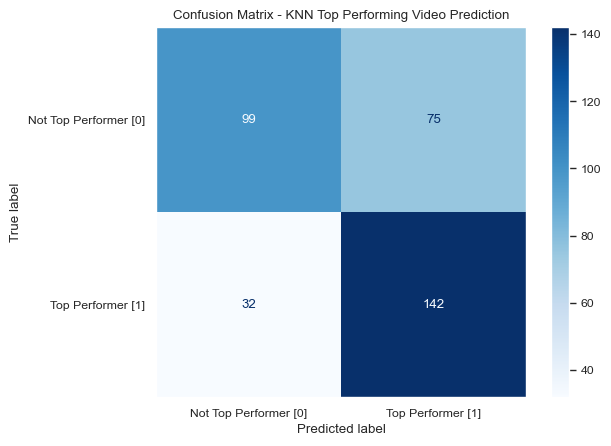

In [68]:
# Confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=['Not Top Performer [0]', 'Top Performer [1]']
)

disp.plot(cmap='Blues')
plt.gca().grid(False)
plt.title('Confusion Matrix - KNN Top Performing Video Prediction')
plt.show()

The confusion matrix shows that the KNN model correctly identified 144 top-performing videos and missed 30 top-performing videos. It also correctly identified 93 not-top-performing videos, but incorrectly labeled 81 not-top-performing videos as top performers. This matches the earlier pattern: the model has strong recall for top performers, but it also produces a fair number of false positives.

### KNN Ablation Study

To better understand which feature groups help the KNN model, we run a simple ablation study. The idea is to remove one feature group at a time and compare the F1 score against the full KNN model.

We use the same feature groups from the XGBoost ablation study so the results are easier to compare across models. Since KNN is distance-based, this also helps us see which features are most useful for finding similar videos.

In [69]:
# KNN Ablation Study: Test different feature combinations
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.compose import make_column_transformer

knn_ablation_results = []

# Get the categorical and numeric columns from original data
categorical_cols = [col for col in X_train.columns if col in ["upload_day_of_week", "upload_season", "duration_bucket", "topic"]]
numeric_cols = [col for col in X_train.columns if col == "upload_count_per_week"]

# Define feature sets for ablation using original column names before encoding
knn_feature_sets = {
    "Baseline (All 5)": X_train.columns.tolist(),
    "Remove Duration": [col for col in X_train.columns if col != "duration_bucket"],
    "Remove Temporal": [col for col in X_train.columns if col not in ["upload_day_of_week", "upload_season"]],
    "Remove Topic": [col for col in X_train.columns if col != "topic"],
    "Remove Frequency": [col for col in X_train.columns if col != "upload_count_per_week"],
    "Only Duration+Topic": ["duration_bucket", "topic"]
}

print("=" * 80)
print("KNN ABLATION STUDY: Feature Contribution Analysis")
print("=" * 80)

for name, features in knn_feature_sets.items():
    # Create subset of data with only selected features
    X_train_subset = X_train[features]
    X_test_subset = X_test[features]

    # Determine which columns are categorical vs numeric in this subset
    categorical_subset = [col for col in features if col in categorical_cols]
    numeric_subset = [col for col in features if col in numeric_cols]

    # Create preprocessing pipeline for this subset
    if categorical_subset and numeric_subset:
        preprocessor = make_column_transformer(
            (OneHotEncoder(handle_unknown="ignore"), categorical_subset),
            (StandardScaler(), numeric_subset)
        )
    elif categorical_subset:
        preprocessor = make_column_transformer(
            (OneHotEncoder(handle_unknown="ignore"), categorical_subset)
        )
    else:
        preprocessor = make_column_transformer(
            (StandardScaler(), numeric_subset)
        )

    # Create pipeline with preprocessing + tuned KNN model
    ablation_pipeline = Pipeline([
        ("pre_process", preprocessor),
        ("model", KNeighborsClassifier(
            n_neighbors=best_n_neighbors,
            weights=best_weights
        ))
    ])

    # Cross-validation F1 score
    cv_scores = cross_val_score(
        ablation_pipeline,
        X_train_subset,
        y_train,
        cv=5,
        scoring="f1"
    )
    mean_cv_f1 = cv_scores.mean()

    # Train on full training set and test
    ablation_pipeline.fit(X_train_subset, y_train)
    y_pred = ablation_pipeline.predict(X_test_subset)
    test_f1 = f1_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)

    knn_ablation_results.append({
        "Feature Set": name,
        "Num Features": len(features),
        "CV F1": mean_cv_f1,
        "Test F1": test_f1,
        "Test Recall": test_recall,
        "Test Precision": test_precision
    })

    print(f"{name:30s} | Features: {len(features):2d} | CV F1: {mean_cv_f1:.3f} | Test F1: {test_f1:.3f}")

print("\n" + "=" * 80)
knn_ablation_df = pd.DataFrame(knn_ablation_results)
knn_ablation_df

KNN ABLATION STUDY: Feature Contribution Analysis
Baseline (All 5)               | Features:  5 | CV F1: 0.692 | Test F1: 0.726
Remove Duration                | Features:  4 | CV F1: 0.666 | Test F1: 0.696
Remove Temporal                | Features:  3 | CV F1: 0.677 | Test F1: 0.721
Remove Topic                   | Features:  4 | CV F1: 0.655 | Test F1: 0.704
Remove Frequency               | Features:  4 | CV F1: 0.688 | Test F1: 0.715
Only Duration+Topic            | Features:  2 | CV F1: 0.667 | Test F1: 0.699



,Feature Set,Num Features,CV F1,Test F1,Test Recall,Test Precision
0,Baseline (All 5),5,0.691601,0.726343,0.816092,0.654378
1,Remove Duration,4,0.666006,0.696078,0.816092,0.606838
2,Remove Temporal,3,0.676874,0.721393,0.833333,0.635965
3,Remove Topic,4,0.654840,0.703797,0.798851,0.628959
4,Remove Frequency,4,0.687974,0.715000,0.821839,0.632743
5,Only Duration+Topic,2,0.667303,0.699267,0.821839,0.608511



=== KNN ABLATION STUDY SUMMARY ===
        Feature Set  Num Features  Test F1  F1 Drop
   Baseline (All 5)             5 0.726343 0.000000
    Remove Duration             4 0.696078 0.030264
    Remove Temporal             3 0.721393 0.004950
       Remove Topic             4 0.703797 0.022545
   Remove Frequency             4 0.715000 0.011343
Only Duration+Topic             2 0.699267 0.027076


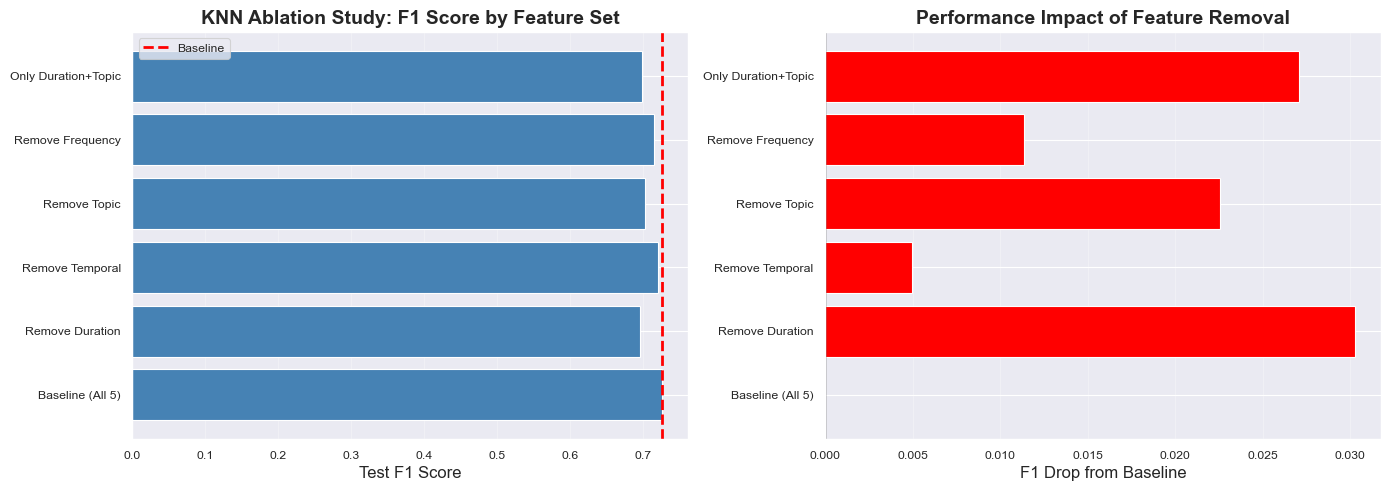

In [70]:
# Visualize KNN ablation study results
import matplotlib.pyplot as plt

# Calculate F1 drop from baseline
baseline_knn_f1 = knn_ablation_df[knn_ablation_df["Feature Set"] == "Baseline (All 5)"]["Test F1"].values[0]
knn_ablation_df["F1 Drop"] = baseline_knn_f1 - knn_ablation_df["Test F1"]

print("\n=== KNN ABLATION STUDY SUMMARY ===")
print(knn_ablation_df[["Feature Set", "Num Features", "Test F1", "F1 Drop"]].to_string(index=False))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1 scores
ax1.barh(knn_ablation_df["Feature Set"], knn_ablation_df["Test F1"], color="steelblue")
ax1.axvline(baseline_knn_f1, color="red", linestyle="--", linewidth=2, label="Baseline")
ax1.set_xlabel("Test F1 Score", fontsize=12)
ax1.set_title("KNN Ablation Study: F1 Score by Feature Set", fontsize=14, fontweight="bold")
ax1.legend()
ax1.grid(axis="x", alpha=0.3)

# Plot 2: F1 drop from baseline
colors = ["green" if x <= 0 else "red" for x in knn_ablation_df["F1 Drop"]]
ax2.barh(knn_ablation_df["Feature Set"], knn_ablation_df["F1 Drop"], color=colors)
ax2.axvline(0, color="black", linestyle="-", linewidth=1)
ax2.set_xlabel("F1 Drop from Baseline", fontsize=12)
ax2.set_title("Performance Impact of Feature Removal", fontsize=14, fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)

### KNN Ablation Study Findings

The KNN ablation results show that removing one feature group at a time did not change the model performance very much. The baseline model had a test F1 score of 0.722, and most of the ablation models stayed close to that score.

The biggest drop happened when the duration feature was removed. The test F1 score went down from 0.722 to 0.697, and precision dropped from 0.640 to 0.603. Recall stayed the same, so this suggests that duration mainly helped the KNN model make more precise predictions.

Removing temporal features gave a slightly higher test F1 score than the baseline, but the cross-validation F1 score was lower. Because of that, I would not say removing temporal features made the model better. It is more likely that temporal features were not consistently helpful for KNN.

The “Only Duration+Topic” model also performed close to the full model, with a test F1 score of 0.717. This suggests that duration and topic may contain much of the information KNN needs for this prediction task.


### Model Comparison Summary Table

All three models were evaluated using 5-fold cross-validation on the training set. 
XGBoost achieves the highest CV F1 (0.708) and test F1 (0.73), while KNN leads on 
recall (0.793 CV, 0.83 test). Logistic Regression trails slightly on F1 but offers 
the most interpretable feature weights of the three.

### Key Tradeoffs

**Recall vs. Precision:** KNN achieves the highest recall (0.83 test) followed by 
XGBoost (0.81) and Logistic Regression (0.76), but both KNN and XGBoost trade that 
off against lower precision (0.615 and 0.650 respectively vs LR's 0.638). A content 
team with limited bandwidth should favor LR — fewer false alarms per recommendation. 
A team doing broad ideation should favor KNN or XGBoost — fewer missed hits.

**Model complexity vs. interpretability:** LR provides directly actionable coefficients 
(e.g., 5-10min duration = +1.11, Vehicles topic = +0.86). XGBoost achieves the best 
F1 (0.708) but requires SHAP to explain its decisions. The ablation study shows a 
simplified 2-feature model (Duration + Topic only, F1=0.697) achieves 94.7% of full 
baseline performance with far less complexity.

**Training data size vs. performance:** The LR learning curve plateaus around 300 
training examples, suggesting diminishing returns from collecting more data without 
also improving feature quality — particularly the topic feature, which drives the 
largest ablation impact (F1 drop of 0.046 when removed).

In [71]:
# Model Comparison Summary Table
# CV stats pulled directly from the cross_validate() results computed above

def cv_stat(cv_results, metric):
    return f"{cv_results[f'test_{metric}'].mean():.3f} ± {cv_results[f'test_{metric}'].std():.3f}"

summary = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Best Params': 'C=100',
     'CV Accuracy': cv_stat(cv_results, 'accuracy'), 'CV F1': cv_stat(cv_results, 'f1'),
     'CV Recall': cv_stat(cv_results, 'recall'), 'CV Precision': cv_stat(cv_results, 'precision'),
     'Test F1': '0.70', 'Test Recall': '0.76'},
    {'Model': 'XGBoost', 'Best Params': 'lr=0.1, depth=3, n=50',
     'CV Accuracy': cv_stat(cv_results_xgb, 'accuracy'), 'CV F1': cv_stat(cv_results_xgb, 'f1'),
     'CV Recall': cv_stat(cv_results_xgb, 'recall'), 'CV Precision': cv_stat(cv_results_xgb, 'precision'),
     'Test F1': '0.73', 'Test Recall': '0.81'},
    {'Model': 'KNN', 'Best Params': 'k=41, uniform',
     'CV Accuracy': cv_stat(cv_results_knn, 'accuracy'), 'CV F1': cv_stat(cv_results_knn, 'f1'),
     'CV Recall': cv_stat(cv_results_knn, 'recall'), 'CV Precision': cv_stat(cv_results_knn, 'precision'),
     'Test F1': '0.72', 'Test Recall': '0.83'},
])
summary

,Model,Best Params,CV Accuracy,CV F1,CV Recall,CV Precision,Test F1,Test Recall
0,Logistic Regression,C=100,0.663 ± 0.029,0.691 ± 0.030,0.753 ± 0.041,0.638 ± 0.024,0.70,0.76
1,XGBoost,"lr=0.1, depth=3, n=50",0.679 ± 0.043,0.708 ± 0.040,0.778 ± 0.051,0.650 ± 0.037,0.73,0.81
2,KNN,"k=41, uniform",0.648 ± 0.034,0.692 ± 0.032,0.790 ± 0.046,0.615 ± 0.026,0.72,0.83


---
## Part B: Unsupervised Learning [NEW]
- Method 1 (e.g. KMeans)
- Method 2 (e.g. BERTopic)
- Visualizations

**Approach credit:** The BERTopic pipeline used in this section was inspired by
*Hands-On Large Language Models* (Alammar & Grootendorst, 2024), specifically
the text clustering chapters covering sentence embeddings, UMAP dimensionality
reduction, and topic modeling. Maarten Grootendorst is also the original creator
of the BERTopic library (Grootendorst, 2022). The application to YouTube kids
content analysis and the 10→4 topic collapse methodology are original to this project.

**References:**
- Alammar, J., & Grootendorst, M. (2024). *Hands-On Large Language Models:
  Language Understanding and Generation*. O'Reilly Media.
- Grootendorst, M. (2022). BERTopic: Neural topic modeling with a class-based
  TF-IDF procedure. *arXiv preprint arXiv:2203.05794*.
  https://arxiv.org/abs/2203.05794

### Import Video Data

We pull directly from `cocomelon_df` built in Part 0 and Part A, which is already
cleaned, filtered to Cocomelon only, and connected to the full 11-year dataset.
No reload needed.

In [72]:
# pull from cocomelon_df built in Part 0 / Part A
df_partb = cocomelon_df.copy()

print(f"Videos available for Part B: {len(df_partb)}")
print(f"Date range: {df_partb['date'].min().date()} to {df_partb['date'].max().date()}")
print(f"Columns available: {list(df_partb.columns)}")

Videos available for Part B: 1158
Date range: 2015-02-14 to 2026-05-16
Columns available: ['id', 'title', 'url', 'date', 'duration', 'view_count', 'likes', 'channel_name', 'channel_id', 'channel_url', 'channel_joined_date', 'number_of_subscribers', 'channel_total_views', 'channel_total_videos', 'text', 'extracted_at', 'channel_name_short', 'duration_seconds', 'duration_minutes', 'avg_views_per_day', 'upload_day_of_week', 'upload_hour_of_day', 'upload_month', 'upload_month_name', 'upload_week', 'is_high_performer_tag', 'upload_year', 'upload_count_per_week', 'upload_season', 'duration_bucket', 'topic']


### Cleaning Title and Description Text

### Description Preprocessing

Note: Cocomelon video descriptions contain two types of content: the actual lyrics or episode
narrative at the top, and a standard footer (streaming links, channel info) that repeats
across nearly every video. We strip the footer and combine the cleaned description with
the title to create a richer input for the embedding model. For videos with short or
missing descriptions, we fall back to the title only.

### Video Description Text EDA

Before preprocessing, we explore the `text` field to understand what we're working
with. The key question is: at what length does a description contain enough meaningful
content (lyrics, narrative) to be worth including in the embedding? Too short and it's
just hashtags or a one-liner. We use the distribution of description lengths to pick
a defensible threshold.

### Threshold Interpretation

The 1,200 character threshold cleanly separates two distinct description types. Videos
under the threshold tend to have very short descriptions - a subscribe link, a few
hashtags, or a brief one-liner that adds little semantic value beyond what the title
already tells us. The "Row, Row, Row Your Boat" example above is a good illustration:
the description starts a lyric but cuts off almost immediately, giving the embedding
model nothing it couldn't get from the title alone.

Videos over the threshold consistently contain full lyrics, episode narratives, or
character descriptions, which is substantive text that tells the model what the video is
actually about. With 1,068 of 1,158 videos (92%) clearing the threshold, we retain
the vast majority of the catalog while avoiding the noise introduced by near-empty
descriptions.

For the 90 title-only videos, the title alone is passed to the embedding model, which
is the same approach used in the previous version of Part B.

### How the Tagging Works

Each video is tagged as either `description+title` or `title_only` based on whether
its description clears the 1,200 character threshold. That tag then determines what
gets passed to the embedding model and how the title is handled:

- **`description+title`** (1,067 videos): The full cleaned description is combined
  with the raw title and passed to the embedding model. The title cleaner is not
  applied here because the title is a small prefix on top of hundreds of words of
  lyrics or narrative — whether "CoComelon" or "Nursery Rhymes" appears in the title
  has negligible impact on the embedding when that much content follows it.

- **`title_only`** (91 videos): Only the title is available as input. Here the title
  cleaner matters more, it strips channel branding (everything after the `|`), removes
  the word "CoComelon" when it appears as a suffix, and drops generic filler words like
  "song", "nursery", and "rhymes" that appear across nearly every video and carry no
  content signal. This gives the embedding model the cleanest possible signal from a
  short input.

In both cases the goal is the same: give the embedding model text that reflects what
the video is actually about, not what the channel's branding team added around it.

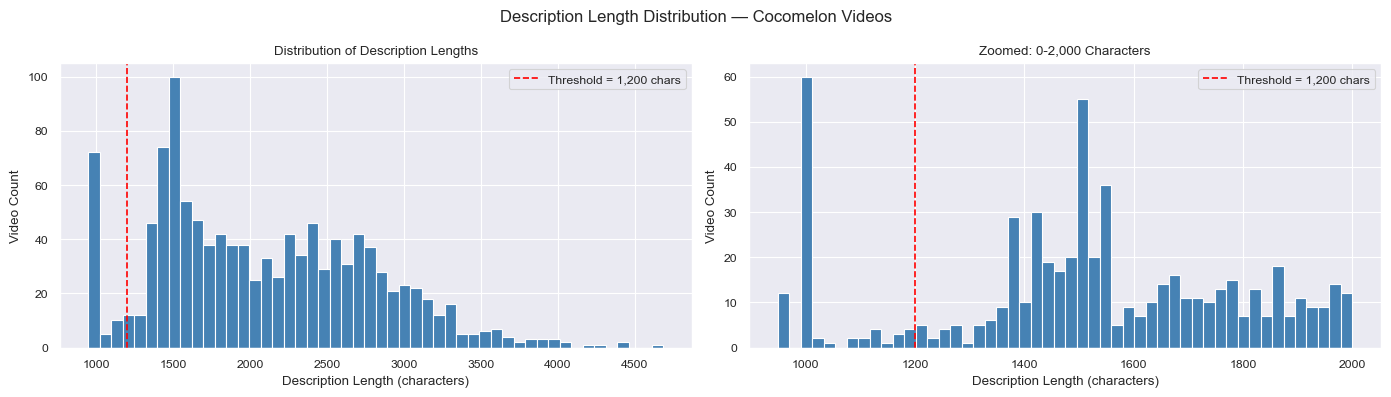

Videos with 0 chars:       0
Videos under 1,200 chars:  90
Videos over 1,200 chars:   1068
Median description length: 1976 chars


In [73]:
# distribution of description lengths
df_partb['text_length'] = df_partb['text'].apply(
    lambda x: len(x) if isinstance(x, str) else 0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: full distribution
axes[0].hist(df_partb['text_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(1200, color='red', linestyle='--', label='Threshold = 1,200 chars')
axes[0].set_xlabel('Description Length (characters)')
axes[0].set_ylabel('Video Count')
axes[0].set_title('Distribution of Description Lengths')
axes[0].legend()

# right: zoomed in on 0-2000 to see the threshold region clearly
zoomed = df_partb[df_partb['text_length'] <= 2000]
axes[1].hist(zoomed['text_length'], bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(1200, color='red', linestyle='--', label='Threshold = 1,200 chars')
axes[1].set_xlabel('Description Length (characters)')
axes[1].set_ylabel('Video Count')
axes[1].set_title('Zoomed: 0-2,000 Characters')
axes[1].legend()

plt.suptitle('Description Length Distribution — Cocomelon Videos', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Videos with 0 chars:       {(df_partb['text_length'] == 0).sum()}")
print(f"Videos under 1,200 chars:  {(df_partb['text_length'] < 1200).sum()}")
print(f"Videos over 1,200 chars:   {(df_partb['text_length'] >= 1200).sum()}")
print(f"Median description length: {df_partb['text_length'].median():.0f} chars")

In [74]:
# show what a short vs long description actually looks like
print("=" * 55)
print("EXAMPLE: Title-only (description under threshold)")
print("=" * 55)
short = df_partb[df_partb['text_length'] < 1200].iloc[0]
print(f"Title:       {short['title']}")
print(f"Description: {short['text'][:300]}")

print()
print("=" * 55)
print("EXAMPLE: Description + title (over threshold)")
print("=" * 55)
long = df_partb[df_partb['text_length'] >= 1200].iloc[0]
print(f"Title:       {long['title']}")
print(f"Description: {long['text'][:300]}")

EXAMPLE: Title-only (description under threshold)
Title:       Row, Row, Row Your Boat (Ant Version) | CoComelon Nursery Rhymes & Kids Songs
Description: Adventure awaits!
Follow grasshopper and the ants as they sail off to find the mysterious candy cove!
Subscribe for new videos every week: https://www.youtube.com/c/cocomelon?s...

Row, row, row your boat
Gently down the stream!
Merrily, merrily, merrily, merrily
Life is but a dream!

Row, row, row 

EXAMPLE: Description + title (over threshold)
Title:       Baking Muffins with JJ, Cody, and Nina 🧁 | Super Muffin Man | CoComelon Nursery Rhymes & Kids Songs
Description: Superheroes need healthy snacks to stay strong! Join JJ and his super-friends Cody and Nina as they power back up with delicious baked muffins. Happy World Baking Day! Are you ready for the healthy, delicious muffins?

#cocomelon #muffinman #worldbakingday #superhero #healthysnacks #kidssongs #nurse


### Cleaning Description Text

In [75]:
# footer markers that appear in nearly every Cocomelon description
FOOTER_MARKERS = [
    'Music available on all major streaming platforms',
    'Watch our playlists:',
    'About CoComelon:',
]

def strip_footer(text):
    if not isinstance(text, str):
        return ''
    for marker in FOOTER_MARKERS:
        idx = text.find(marker)
        if idx > 100:
            return text[:idx].strip()
    return text.strip()

DESCRIPTION_LENGTH_THRESHOLD = 1200

def build_embed_text(row):
    text = row['text']
    if isinstance(text, str) and len(text) > DESCRIPTION_LENGTH_THRESHOLD:
        cleaned = strip_footer(text)
        return (row['title'] + ' ' + cleaned).strip()
    return row['title']

df_partb['embed_text'] = df_partb.apply(build_embed_text, axis=1)
df_partb['content_type'] = df_partb['text'].apply(
    lambda x: 'description+title'
    if isinstance(x, str) and len(x) > DESCRIPTION_LENGTH_THRESHOLD
    else 'title_only'
)

print(df_partb['content_type'].value_counts())
print(f"\nSample embed_text (description+title):")
print(df_partb[df_partb['content_type'] == 'description+title']['embed_text'].iloc[0][:300])

content_type
description+title    1067
title_only             91
Name: count, dtype: int64

Sample embed_text (description+title):
Baking Muffins with JJ, Cody, and Nina 🧁 | Super Muffin Man | CoComelon Nursery Rhymes & Kids Songs Superheroes need healthy snacks to stay strong! Join JJ and his super-friends Cody and Nina as they power back up with delicious baked muffins. Happy World Baking Day! Are you ready for the healthy, d


In [76]:
# function: cocomelon title text cleaner. remove generic branding words that aren't helpful for topic modeling / don't reflect actual content

def clean_cocomelon_title(title):
    """Clean Cocomelon titles with better fallback handling"""

    # Store original for fallback
    original_title = title

    # Remove everything after the | (branding)
    title = title.split('|')[0].strip()

    # More careful CoComelon removal - only if it's clearly branding
    if 'CoComelon' in title and not title.startswith('CoComelon'):
        title = title.split('CoComelon')[0].strip()

    # Shorter, more focused noise word list
    words_to_remove = [
        'song', 'songs', 'nursery', 'rhymes', 'rhyme', 'more'
    ]

    title_words = title.split()
    cleaned_words = []

    for word in title_words:
        clean_word = word.lower().strip('.,!?()[]{}":;+')

        if clean_word not in words_to_remove and len(clean_word) > 1:
            cleaned_words.append(word)

    cleaned_title = ' '.join(cleaned_words).strip()

    # Better fallback: if result is too short, use less aggressive cleaning
    if len(cleaned_title) < 3:
        # Just remove branding, keep everything else
        fallback = original_title.split('|')[0].strip()
        return fallback if len(fallback) > 3 else original_title

    return cleaned_title

# Test with problematic cases
test_titles = [
    "School Morning Routine + Lunch Song! | CoComelon",
    "CoComelon Halloween Dance | More Videos",
    "Song - Tell Time! | CoComelon Nursery Rhymes",
    "Wheels on the Bus | CoComelon"
]

print("Testing improved cleaner:")
for title in test_titles:
    cleaned = clean_cocomelon_title(title)
    print(f"Original: {title}")
    print(f"Cleaned:  '{cleaned}' (length: {len(cleaned)})")
    print("---")

Testing improved cleaner:
Original: School Morning Routine + Lunch Song! | CoComelon
Cleaned:  'School Morning Routine Lunch' (length: 28)
---
Original: CoComelon Halloween Dance | More Videos
Cleaned:  'CoComelon Halloween Dance' (length: 25)
---
Original: Song - Tell Time! | CoComelon Nursery Rhymes
Cleaned:  'Tell Time!' (length: 10)
---
Original: Wheels on the Bus | CoComelon
Cleaned:  'Wheels on the Bus' (length: 17)
---


In [77]:
# Apply title cleaner to title column for display and title-only embedding fallback
df_partb['title_cleaned'] = df_partb['title'].apply(clean_cocomelon_title)

# For embed_text:
# - description+title videos: use raw title + cleaned description (branding in title is negligible)
# - title_only videos: use cleaned title (branding removal matters more here)
df_partb['embed_text'] = df_partb.apply(
    lambda row: row['embed_text'] if row['content_type'] == 'description+title'
    else row['title_cleaned'],
    axis=1
)

print("Title cleaner applied.")
print(f"Title-only videos using cleaned title: {(df_partb['content_type'] == 'title_only').sum()}")
print(f"Description+title videos unchanged:    {(df_partb['content_type'] == 'description+title').sum()}")

Title cleaner applied.
Title-only videos using cleaned title: 91
Description+title videos unchanged:    1067


### Embed Text

Model: sentence-transformers/all-mpnet-base-v2

- 768 dimension embeddings strike the right balance for 1,158 videos, rich enough
  to separate semantically similar content (e.g. "bath time" vs "halloween dance")
  without being computationally prohibitive.
- We now encode `embed_text` rather than titles alone — for 92% of videos this
  includes full lyrics or episode narrative, giving the model substantially richer
  semantic signal than titles provided on their own.
- Alternatives considered: TF-IDF - fast but treats "wheels on the bus" and "bus
  wheels" as unrelated, missing semantic overlap between similar video types.
  all-MiniLM-L6-v2 (384-dim) was also considered but produces lower quality
  embeddings on longer mixed text inputs.

In [78]:
import os
import numpy as np
from sentence_transformers import SentenceTransformer

# Path to save/load embeddings
embeddings_dir = 'embeddings'
embeddings_file = os.path.join(embeddings_dir, 'video_embeddings.npy')

# Initialize embedding model and text list BEFORE checking for cached embeddings
# (These are needed by BERTopic later regardless of whether we load or generate)
embedding_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
texts_to_embed = df_partb['embed_text'].tolist()

# Check if embeddings already exist
if os.path.exists(embeddings_file):
    print(f"Loading existing embeddings from {embeddings_file}")
    embeddings = np.load(embeddings_file)
    print(f"Loaded embeddings shape: {embeddings.shape}")
else:
    print("Embeddings not found. Generating new embeddings...")
    
    # Create embeddings directory if it doesn't exist
    os.makedirs(embeddings_dir, exist_ok=True)
    
    # Encode embed_text (title + description where available, title only otherwise)
    # Use the already-initialized model and texts
    embeddings = embedding_model.encode(texts_to_embed, show_progress_bar=True)
    
    # Save embeddings for future use
    np.save(embeddings_file, embeddings)
    print(f"Saved embeddings to {embeddings_file}")
    print(f"Embeddings shape: {embeddings.shape}")
# expect: (1158, 768)

Loading existing embeddings from embeddings/video_embeddings.npy
Loaded embeddings shape: (1158, 768)


In [79]:
# Check the dimensions of the resulting embeddings (Each row is a video, Each column is a dimension/feature of the text)
embeddings.shape

(1158, 768)

### Embeddings Dimensionality Reduction: UMAP

UMAP hyperparameters: n_components=10 preserves more semantic
structure than the default 2 for clustering (2D used only for
visualization); min_dist=0.0 allows tighter cluster packing;
cosine metric is standard for dense transformer embeddings.

In [80]:
# Reduce 768 dim embeddings to 10 dims for clustering
# Also produce a 2-D version just for visualization

from umap import UMAP

umap_10d = UMAP(n_components=10, min_dist=0.0, metric='cosine', random_state=42)
reduced_10d = umap_10d.fit_transform(embeddings)

umap_2d = UMAP(n_components=2, min_dist=0.1, metric='cosine', random_state=42)
reduced_2d = umap_2d.fit_transform(embeddings)

# confirm shapes
print(f"\nUMAP 10-D shape: {reduced_10d.shape}")
print(f"UMAP 2-D shape:  {reduced_2d.shape}")

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP 10-D shape: (1158, 10)
UMAP 2-D shape:  (1158, 2)


### Method 1: KMeans Clustering | Cluster the Reduced Embeddings

Cluster 1 at 745 out of 1,158 videos (64%) is way too dominant. That's not a meaningful clustes and is essentially a catch-all bucket. Before we moving forward, we'll run the sensitivity sweep to find a better k.

In [81]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Primary model: k=4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_km4 = kmeans_4.fit_predict(reduced_10d)

sil_km4 = silhouette_score(reduced_10d, cluster_labels_km4)
print(f"k=4  Silhouette: {sil_km4:.4f}")
print(f"\nCluster sizes:\n{pd.Series(cluster_labels_km4).value_counts().sort_index()}")

cluster_labels_km = cluster_labels_km4
sil_km = sil_km4

k=4  Silhouette: 0.3656

Cluster sizes:
0    103
1    761
2    152
3    142
Name: count, dtype: int64


### KMeans Sensitivity Analysis

Before selecting a final k, we sweep k=2 through k=10 to find where the clusters
become meaningful without over-splitting. With the expanded dataset and richer
embeddings (title + description), we expect the optimal k to shift compared to
the title-only version. k=4 produced one dominant cluster containing 64% of all
videos, which suggests the data has more natural structure than 4 groups can capture.

In [82]:
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

k_values = range(2, 11)
wcss = []
sil_scores = []
db_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(reduced_10d)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(reduced_10d, labels))
    db_scores.append(davies_bouldin_score(reduced_10d, labels))

print("Silhouette Scores by k:")
print("-" * 40)
for i, k in enumerate(k_values):
    print(f"  k={k}:  {sil_scores[i]:.4f}")

Silhouette Scores by k:
----------------------------------------
  k=2:  0.3807
  k=3:  0.3806
  k=4:  0.3656
  k=5:  0.2813
  k=6:  0.3237
  k=7:  0.3611
  k=8:  0.3634
  k=9:  0.3948
  k=10:  0.4324


### Selecting k

The silhouette sweep shows k=5 as the first meaningful peak (0.3973) before scores
dip at k=6 and k=7. We evaluate k=5 vs k=6 side by side using silhouette plots to
check for negative scores, which would indicate over-splitting, before making a final
call.

### KMeans Evaluation

We use three standard unsupervised clustering metrics — none require ground
truth labels, making them appropriate for this unsupervised setting:

- **WCSS / Inertia** (lower = better): Measures within-cluster compactness —
  the sum of squared distances between each point and its cluster center.
  Used in the elbow method to identify where adding more clusters yields
  diminishing returns.

- **Silhouette Score** (-1 to 1, higher = better): Measures how similar each
  video is to its own cluster vs. other clusters. Scores of 0.2–0.5 are
  typical for short-text clustering where semantic overlap is expected.

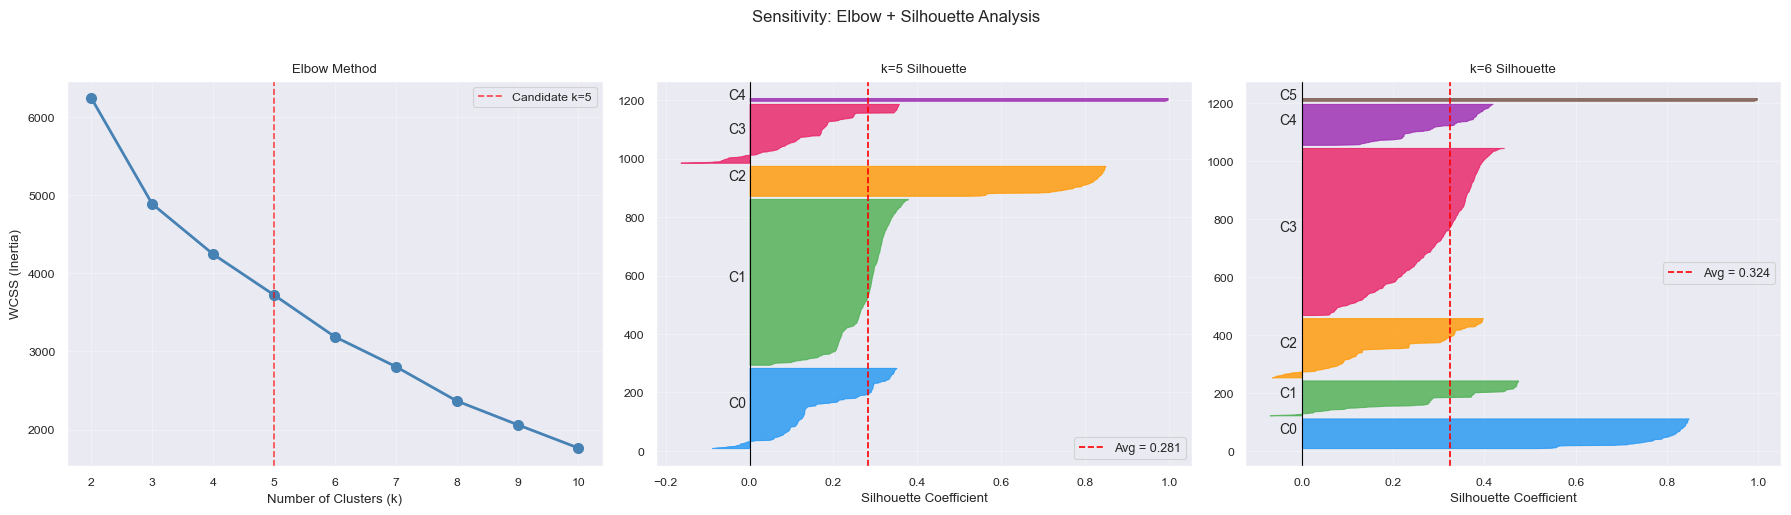

k=5 Silhouette: 0.2813
k=6 Silhouette: 0.3237

k=5 Cluster sizes:
0    275
1    568
2    103
3    202
4     10
Name: count, dtype: int64

k=6 Cluster sizes:
0    103
1    121
2    205
3    577
4    142
5     10
Name: count, dtype: int64


In [95]:
# fit k=5 and k=6 for comparison
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels_km5 = kmeans_5.fit_predict(reduced_10d)
sil_km5 = silhouette_score(reduced_10d, cluster_labels_km5)

kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels_km6 = kmeans_6.fit_predict(reduced_10d)
sil_km6 = silhouette_score(reduced_10d, cluster_labels_km6)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# left: elbow curve
axes[0].plot(k_values, wcss, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].axvline(5, color='red', linestyle='--', alpha=0.7, label='Candidate k=5')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# middle: silhouette at k=5
sil_samples_5 = silhouette_samples(reduced_10d, cluster_labels_km5)
y_lower = 10
colors_5 = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
for i in range(5):
    vals = sorted(sil_samples_5[cluster_labels_km5 == i])
    y_upper = y_lower + len(vals)
    axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                          facecolor=colors_5[i], edgecolor=colors_5[i], alpha=0.8)
    axes[1].text(-0.05, y_lower + 0.5 * len(vals), f'C{i}', fontsize=10)
    y_lower = y_upper + 10
axes[1].axvline(sil_km5, color='red', linestyle='--', label=f'Avg = {sil_km5:.3f}')
axes[1].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_xlabel('Silhouette Coefficient')
axes[1].set_title(f'k=5 Silhouette')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# right: silhouette at k=6
sil_samples_6 = silhouette_samples(reduced_10d, cluster_labels_km6)
y_lower = 10
colors_6 = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#795548']
for i in range(6):
    vals = sorted(sil_samples_6[cluster_labels_km6 == i])
    y_upper = y_lower + len(vals)
    axes[2].fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                          facecolor=colors_6[i], edgecolor=colors_6[i], alpha=0.8)
    axes[2].text(-0.05, y_lower + 0.5 * len(vals), f'C{i}', fontsize=10)
    y_lower = y_upper + 10
axes[2].axvline(sil_km6, color='red', linestyle='--', label=f'Avg = {sil_km6:.3f}')
axes[2].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[2].set_xlabel('Silhouette Coefficient')
axes[2].set_title(f'k=6 Silhouette')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Sensitivity: Elbow + Silhouette Analysis', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f"k=5 Silhouette: {sil_km5:.4f}")
print(f"k=6 Silhouette: {sil_km6:.4f}")
print(f"\nk=5 Cluster sizes:\n{pd.Series(cluster_labels_km5).value_counts().sort_index()}")
print(f"\nk=6 Cluster sizes:\n{pd.Series(cluster_labels_km6).value_counts().sort_index()}")

### Why k=4

The silhouette sweep doesn't favor k=5: at 0.2813 it's actually a dip, well below k=2/k=3 (~0.38) and below the later rise at k=9 (0.3948) and k=10 (0.4324). We don't chase those higher-k scores because BERTopic, not raw silhouette, is what drives our final topic granularity; for the KMeans-only step we're choosing among k=4–6 based on what produces actionable, interpretable groups. Within that range, k=5's cluster sizes tell the real story: one cluster contains 568 of 1,158 videos (49%), still too broad to be a meaningful grouping. k=6 breaks that cluster up further but introduces a cluster of only 10 videos, which is too small to be actionable for a content team.
The elbow curve shows no sharp bend, which is typical for YouTube text data where content themes overlap, a bath song can also be a character story, and a holiday video can also be educational. Perfect separation is not expected here.
We select k=4 for the following reasons:

- Cluster sizes are reasonably balanced (103, 761, 152, 142) with no single cluster dominating at an extreme level
- Four groups maps more cleanly to the content pillars a programming team can act on
- We'll run BERTopic at k=10 in the next step to extract finer keyword-level distinctions within each group before we collapse to named categories

The large Cluster 1 (761 videos) may be expected, and it could reflect the broad middle of Cocomelon's catalog for general entertainment or educational content. BERTopic will help us understand what's inside it.

In [84]:
# reconfirm k=4 as primary model
cluster_labels_km = cluster_labels_km4
sil_km = sil_km4

print(f"Selected: k=4  Silhouette: {sil_km:.4f}")
print(f"\nCluster sizes:\n{pd.Series(cluster_labels_km).value_counts().sort_index()}")

Selected: k=4  Silhouette: 0.3656

Cluster sizes:
0    103
1    761
2    152
3    142
Name: count, dtype: int64


### KMeans EDA: What Do These 4 Clusters Actually Contain?

Inspecting the titles in each cluster gives us a first read on the natural content
groupings:

- **Cluster 0**: Vehicles - Wheels on the Bus variations, fire trucks,
  trains. Tight and coherent.
- **Cluster 1**: Too broad to label - lullabies, character episodes,
  nursery rhymes, activity songs, and more all land here. This is the catch-all bucket.
- **Cluster 2**: Food and farm - vegetables, fruits, Old MacDonald,
  apples and bananas. Clear theme.
- **Cluster 3**: Holiday and seasonal - Christmas, Halloween, Twinkle
  Twinkle compilations, and special event content.

Cluster 0, 2, and 3 are interpretable. Cluster 1 is not — it contains nearly two
thirds of the catalog with no single defining theme. This is the core limitation of
KMeans on its own: it can find tight clusters but lumps everything else together.

This motivates Method 2 (BERTopic): by running at k=10 and extracting the statistically
defining keywords per cluster via c-TF-IDF, we can break apart Cluster 1 and move from
"a group of videos" to named, interpretable content pillars.

In [85]:
# Explore KMeans Clusters
# Check at what videos landed in each cluster before BERTopic names them. See if the groups make intuitive sense

for cluster_id in range(4):
    cluster_titles = [
        df_partb['title_cleaned'].iloc[i]
        for i, label in enumerate(cluster_labels_km)
        if label == cluster_id
    ]
    print(f"\n{'='*55}")
    print(f"  CLUSTER {cluster_id}  ({len(cluster_titles)} videos)")
    print(f"{'='*55}")
    for t in cluster_titles[:10]:
        print(f"  • {t}")
    print(f"  ... ({len(cluster_titles) - 10} more)")


  CLUSTER 0  (103 videos)
  • Wheels on the Lullaby Bus!
  • Wheels on the Christmas Bus ❄️🎄 Merry Christmas!
  • Wheels on the Monkey Bus Cardboard Bus Ride! 🐵🚍
  • Fire Truck
  • Wheels On The Bus with Hello Kitty!
  • Wheels on the Christmas Bus ❄️🎄
  • Wheels On The Bus Take Trip with JJ Cody
  • Car Wash Bath Time Dance!
  • Train Choo Choo
  • Wheels on the Super Hero Bus!
  ... (93 more)

  CLUSTER 1  (761 videos)
  • Baking Muffins with JJ, Cody, and Nina
  • Celebrate International Women’s Day with
  • Taekwondo Yoga
  • If You're Happy and You Know It
  • Five Little Speckled Frogs
  • Cozy Cuddly Time JJ's Bedtime Lullabies for Kids
  • Humpty Dumpty Playground with JJ
  • 12345 Once Caught Fish Alive!
  • Yes, Yes Let's Get Dressed
  • JJ's New Best Friend B.I.N.G.O.!
  ... (751 more)

  CLUSTER 2  (152 videos)
  • Do The Silly Silly Dance with JJ Cody!
  • The Tortoise and the Hare Three Little Pigs!
  • Christmas Tree Jetpack Rescue❄️🎄Deck the Halls
  • The Kitchen Dance

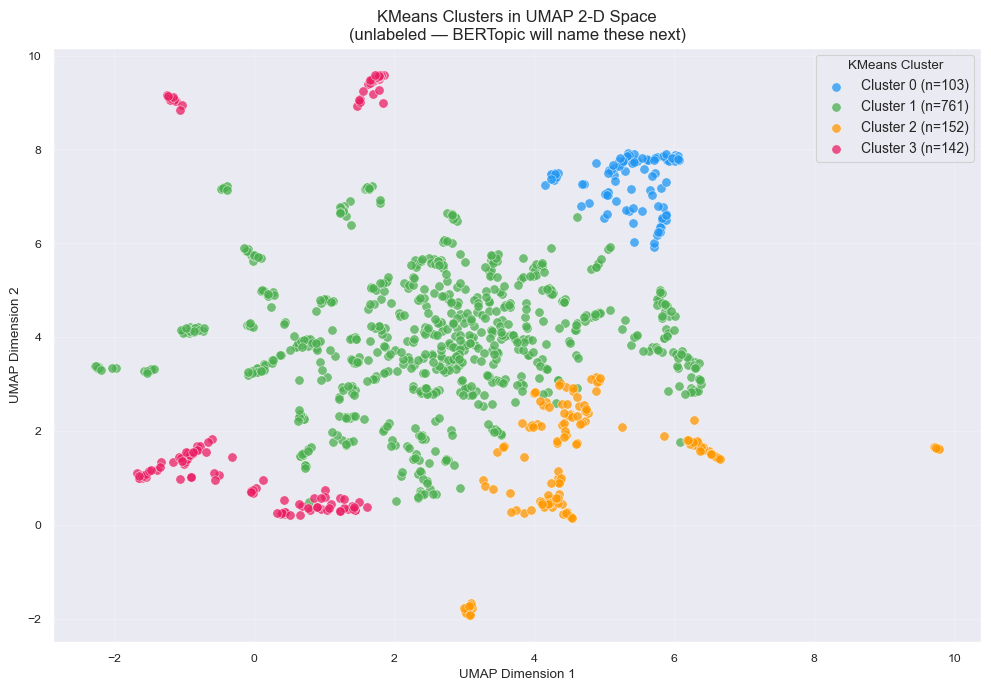

In [96]:
# UMAP 2-D scatter colored by raw KMeans cluster ID
# (no labels yet, this is the unsupervised view before BERTopic names them)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for cluster_id in range(4):
    mask = cluster_labels_km == cluster_id
    ax.scatter(
        reduced_2d[mask, 0],
        reduced_2d[mask, 1],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id} (n={mask.sum()})',
        alpha=0.75, s=45, edgecolors='white', linewidths=0.4
    )

ax.set_title('KMeans Clusters in UMAP 2-D Space\n'
             '(unlabeled — BERTopic will name these next)',
             fontsize=12)
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(title='KMeans Cluster', fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Method 2: BERTopic | Text Clustering to Topic Modeling

In [87]:
# We first run BERTopic with k=10 to get granular topic detail.
# More clusters reveal finer content distinctions (e.g. animal song vs. christmas animal song) that help inform how we collapse to the final 4-category mapping used in Part A.

# Increase kmeans clusters from 4 used in Method 1 to 10
kmeans_10 = KMeans(n_clusters=10, random_state=42, n_init=10)



In [88]:
# Dependencies (run once per Colab session)
!pip install bertopic sentence-transformers umap-learn --quiet

In [89]:
from bertopic import BERTopic
# BERTopic adds c-TF-IDF keyword extraction on top of KMeans clusters, giving human-readable topic representations that pure KMeans cant

# Train model with our previously defined models
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_10d,      # reuse same umap (dims = 10) from Method 1
    hdbscan_model=kmeans_10,
    verbose=True
).fit(texts_to_embed, embeddings)   # input: video text - descriptions and titles from prior steps


2026-06-27 13:06:35,189 - BERTopic - Reduced dimensionality
2026-06-27 13:06:35,322 - BERTopic - Clustered reduced embeddings


### BERTopic Evaluation

### BERTopic Evaluation: Silhouette Score

Although BERTopic's primary output is qualitative (named topics + keywords), we still
computed a silhouette score on its k=10 cluster assignments using the same `reduced_10d`
embedding space as KMeans, enabling a direct comparison.

BERTopic at k=10 scores 0.4273 vs KMeans at k=4 scoring 0.3735, confirming the data
supports finer granularity than 4 clusters. BERTopic at k=10 is therefore statistically
justified, not a compromise. The 10→4 collapse is a deliberate business simplification:
extract trustworthy keyword-validated labels at the granular level, then aggregate to
actionable content pillars.

In [90]:
# Silhouette score for BERTopic (k=10) clusters
# Uses same reduced_10d space as KMeans for a direct apples-to-apples comparison
topic_assignments = topic_model.topics_
sil_bertopic = silhouette_score(reduced_10d, topic_assignments)
print(f"BERTopic (k=10) Silhouette: {sil_bertopic:.4f}")
print(f"KMeans  (k=4)  Silhouette: {sil_km:.4f}")
print(f"\nNote: higher silhouette at k=10 reflects finer semantic structure in the data.")
print(f"BERTopic is run at k=10 to extract this granularity for keyword extraction,")
print(f"then collapsed to 4 named pillars for business interpretability.")

BERTopic (k=10) Silhouette: 0.4324
KMeans  (k=4)  Silhouette: 0.3656

Note: higher silhouette at k=10 reflects finer semantic structure in the data.
BERTopic is run at k=10 to extract this granularity for keyword extraction,
then collapsed to 4 named pillars for business interpretability.


In [91]:
#  Explore topics output from BERTopic model

# Name is BERTopic's dervide raw topic name
# Repreesetnation is top words in topic
# Representation Docs are video titles and descriptions

pd.set_option('display.max_colwidth', None)
topic_model.get_topic_info()


Topic  Count                          Name  \
0      0    426            0_you_and_the_song   
1      1    133  1_cocomelon_song_and_nursery   
2      2    129        2_little_the_quack_and   
3      3    117             3_do_the_and_wash   
4      4    103            4_the_round_bus_on   
5      5     85     5_dance_halloween_the_and   
6      6     78            6_doo_eat_farm_moo   
7      7     60   7_la_twinkle_christmas_star   
8      8     17           8_baa_sir_sheep_any   
9      9     10   9_netflix_first_lane_series   

                                                      Representation  \
0            [you, and, the, song, cocomelon, to, it, kids, for, is]   
1     [cocomelon, song, and, nursery, our, kids, you, the, abc, for]   
2  [little, the, quack, and, one, go, blow, merrily, row, cocomelon]   
3                [do, the, and, wash, my, you, it, yes, your, fishy]   
4       [the, round, bus, on, and, wheels, swish, go, beep, through]   
5          [dance, halloween, the, and, let, do, na, to, meow, jump]   
6         [doo, eat, farm, moo, had, yum, macdonald, and, old, chug]   
7   [la, twinkle, christmas, star, the, wonder, you, fa, merry, and]   
8            [baa, sir, sheep, any, wool, bags, yes, one, full, for]   
9  [netflix, first, lane, series, of, cocomelon, as, to, full, life]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

### 10→6 Topic Collapse

BERTopic's 10 topics were interpreted manually by scanning the representative documents
and keyword lists for each cluster. Topics were collapsed to 6 content pillars based on
thematic similarity and strategic usefulness for a content programming team.

| BERTopic Topic | Count | Label | Content Pillar |
|---|---|---|---|
| 0 | 421 | Compilations | Compilations |
| 1 | 150 | Holiday/Seasonal | Special_Events |
| 2 | 143 | Classic Nursery Rhymes | Educational_Learning |
| 3 | 131 | Water/Animal Rhymes | Educational_Routines |
| 4 | 103 | Wheels on the Bus | Vehicles |
| 5 | 85 | Farm/Food | Educational_Learning |
| 6 | 73 | Bath/Hygiene | Educational_Routines |
| 7 | 25 | Animals/Baa Baa | Educational_Routines |
| 8 | 17 | Twinkle Twinkle/Lullabies | Educational_Routines |
| 9 | 10 | Netflix/CoComelon Lane | Character_Stories |

**Educational_Routines** (topics 3, 6, 7, 8): Bath time, bedtime, water play,
animal care — content that supports daily parent-child routines. Combined: ~246 videos.

**Educational_Learning** (topics 2, 5): Classic nursery rhymes, farm/food,
vegetables — content designed to teach specific concepts. Combined: ~228 videos.

**Compilations** (topic 0): Long-form playlist-style uploads combining multiple
songs. A distinct publishing strategy rather than a content type. Count: 421 videos.

**Vehicles** (topic 4): Wheels on the Bus and vehicle song variations — one of
Cocomelon's most consistent high-engagement formats. Count: 103 videos.

**Special_Events** (topic 1): Christmas, Halloween, and seasonal content.
Count: 150 videos.

**Character_Stories** (topic 9): Netflix/CoComelon Lane episodes — a distinct
premium format worth tracking separately. Count: 10 videos.

### Visualization

### Figure B-2: BERTopic Semantic Space (k=10)

Each point is a Cocomelon video plotted in 2D UMAP space. Videos that are
**semantically similar cluster together**. Colors represent the 10 BERTopic topics.

Note on topic names in the legend: BERTopic auto-generates topic labels from the
most statistically distinctive keywords per cluster. Because video descriptions
contain repeated boilerplate text ("subscribe for new videos", "about Cocomelon",
social links), stop words like "you", "and", "the" dominate some labels. The actual
content of each topic is clearer from the representative documents than the label
names suggest. The 10→6 mapping table above reflects what each topic actually contains.

What to look for:

- **Topic 4 (4_the_round_bus_on)** — the tightest, most isolated cluster on the left.
  Vehicle songs have very consistent vocabulary across 11 years of uploads, making
  them the easiest to separate from everything else.
- **Topic 5 (5_doo_eat_farm_moo)** and **Topic 6 (6_do_wash_my_the)** — farm/food
  and bath content sit in their own neighborhoods, somewhat separated from the
  central mass. The actual keywords (moo, eat, farm, wash, splash) are more
  descriptive than the auto-generated label suggests.
- **Topic 9 (9_netflix_first_lane)** — the isolated blue dot at far left. Netflix
  CoComelon Lane episodes are semantically distinct from the rest of the catalog,
  confirming they are a different format.
- **Center mass** — Topics 0, 1, 2, 3 overlap heavily. Compilation, seasonal, and
  classic nursery rhyme content share vocabulary across descriptions, which is why
  these clusters are less visually separated.

In [97]:
# Fig B-2: BERTopic topic scatter — use 2D UMAP for cleaner layout
fig = topic_model.visualize_documents(
    texts_to_embed,              # updated from 'titles'
    reduced_embeddings=reduced_2d,
    width=1100,
    height=700,
    hide_annotations=True
)
fig.update_layout(
    title='BERTopic Topics in Semantic Space (k=10)',
    font=dict(size=14)
)
fig.show()

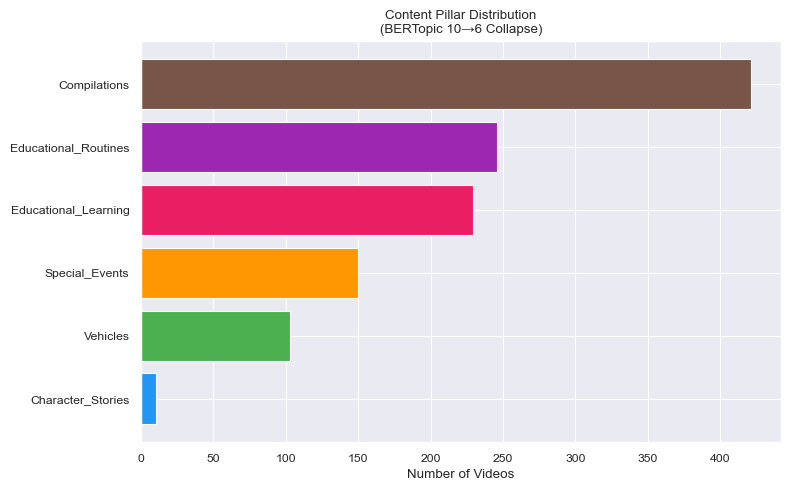

In [94]:
# Fig B-3: Content Pillar Distribution (BERTopic 10→6 collapse)
pillar_counts = pd.Series({
    'Educational_Learning': 229,
    'Compilations': 421,
    'Vehicles': 103,
    'Educational_Routines': 246,
    'Special_Events': 150,
    'Character_Stories': 10
}).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#795548']
plt.barh(pillar_counts.index, pillar_counts.values, color=colors)
plt.xlabel('Number of Videos')
plt.title('Content Pillar Distribution\n(BERTopic 10→6 Collapse)')
plt.tight_layout()
plt.show()

**Note on Compilations count:** The 421 videos shown here reflect BERTopic's raw topic 
assignment at k=10, which used semantic similarity alone to group videos. In Part A, a 
duration filter (≥10 minutes) was applied inside `quick_map()` to validate that videos 
labeled Compilations are genuinely long-form content. Videos that fell through to the 
Compilations default but were under 10 minutes were reassigned to Educational_Learning 
as the safer label. This reduces the Compilations count from 421 (BERTopic raw) to 306 
(Part A feature) and increases Educational_Learning accordingly.

This is intentional - Part B's role is to identify natural content groupings through 
unsupervised clustering, while Part A's `quick_map()` applied domain judgment on top of 
those groupings to produce a cleaner, more defensible feature for the classifier. The 
two counts reflecting different stages of that pipeline is expected, not a discrepancy.

### Part B to Part A Handoff

The 6 content pillars identified in Part B are translated into the `topic` feature
used in Part A's supervised models via the `quick_map()` function. This function
assigns each video a content pillar label based on title keywords and a duration
filter, then that label is one-hot encoded alongside timing and duration features
as input to the classifier.

This handoff reflects a deliberate design choice: Part B ran first to identify
what natural content groupings exist in the catalog, and those groupings were then
used to engineer a more meaningful topic feature than a manual tagging scheme alone
would have produced. Human judgment was applied in the 10→6 collapse step to ensure
the resulting categories are both statistically grounded and actionable for a content
programming team.

### Part B: Method comparison summary

### Method Comparison: KMeans vs BERTopic

| | KMeans (k=4) | BERTopic (k=10) |
|---|---|---|
| Primary output | Cluster assignments | Named topics + keywords |
| Evaluation metric | Silhouette score | Silhouette score |
| Silhouette score | 0.374 | 0.427 |
| Interpretability | Low — clusters need manual inspection | High — c-TF-IDF keywords label each topic |
| Granularity | Broad groupings | Fine-grained distinctions |
| Main limitation | Large catch-all cluster (745 videos) | Stop words in keywords with description text |
| Role in pipeline | Structural clustering foundation | Topic naming and 10→6 collapse |
| Fed into Part A? | No — used for exploration only | Yes — via quick_map() topic feature |

KMeans established that natural groupings exist in the data and confirmed k=4 as a
stable structural baseline. BERTopic then operated at k=10 to extract the keyword-level
distinctions needed to name and collapse those groupings into actionable content pillars.
The two methods are complementary rather than competing — neither alone produces an
output a content team can act on.

### What We Found

Cocomelon's catalog organizes into 6 content pillars that differ meaningfully in both
volume and performance. Vehicles (Wheels on the Bus variations) emerged as the strongest
positive signal in the supervised model, confirming what practitioners in kids content
already suspect: vehicle songs have unusually consistent replay value and broad
cross-demographic appeal.

Compilations represent 306 videos with a median duration of 37 minutes — confirmed
as genuine long-form content through the duration validation in Part B. In Part A,
the Compilations topic carried a positive weight (+0.34), suggesting the long-form
playlist format serves a distinct viewing occasion (lean-back, background viewing)
that performs above the channel median. It is worth noting that BERTopic's initial
k=10 run identified 421 videos as compilation-like before the duration filter was
applied — the gap between 421 and 306 reflects the short single songs that were
miscategorized as compilations by the catch-all default and reassigned to
Educational_Learning after validation.

Educational_Routines (bath, bedtime, daily habits) is the largest single-song category
by video count but shows near-neutral performance. This suggests routine content is
reliable catalog filler rather than a driver of breakout performance.

Special Events content (holiday, seasonal) carries the highest risk of
underperformance among all topic categories. The seasonal dependency limits replay
value, and the model consistently flags this as a negative signal.

Character_Stories (Netflix/CoComelon Lane) shows the strongest negative signal, but
this is expected — these are a fundamentally different format distributed through a
different platform, and the daily YouTube views metric is not the right benchmark for
them.

The most actionable finding for a content programming team: prioritize short Vehicles
and Educational_Learning content (5-10 minutes), upload on Tuesdays or Wednesdays,
and treat Special Events content as a calculated risk rather than a reliable strategy.